In [ ]:
# STAT Agent Analysis Session
# Started: 2026-04-17 01:57:30

# Import required libraries
from stat_agent.core.session import SimpleSession
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Initialize session
session = SimpleSession()

# Load dataset
session.load_dataset('./data/processed')  # adjust to your local path

# LLM configuration (from web interface session)
session.llm_config = {
    'api_key': 'YOUR_API_KEY_HERE'  # set your Poe / OpenAI-compatible key,
    'model': 'poe/Claude-Sonnet-4.6',
    'base_url': 'https://api.poe.com/v1'
}

# Quick access
slice_0 = session.get_slice(0)
adata = slice_0.adata if slice_0 else None

print(f'Loaded {len(session.slices)} slice(s)')
if adata is not None:
    print(f'Slice 0: {adata.n_obs} cells, {adata.n_vars} genes')

In [ ]:
# Setup: Load all STAT skills
import sys, os
from pathlib import Path

try:
    import stat_agent
    SKILLS_DIR = Path(stat_agent.__file__).parent.parent / '.claude' / 'skills'
except ImportError:
    SKILLS_DIR = Path(os.environ.get('STAT_SKILLS_DIR', './skills'))

if SKILLS_DIR.exists():
    for p in SKILLS_DIR.iterdir():
        if p.is_dir() and not p.name.startswith('.'):
            sys.path.insert(0, str(p))
    print(f'Loaded {len([p for p in SKILLS_DIR.iterdir() if p.is_dir()])} skills')
else:
    print(f'Skills directory not found: {SKILLS_DIR}')


Processing Slice 0 | tumor label: 'Tumor II'
  Using column: DeconvolutionLabel1
  Total spots:  235,530
  Tumor spots:  119,456
  Seed tumor spots (≥25 tumor neighbours in 50 µm): 118,973
  Periphery spots: 17,371

  region_label counts:
    Tumor       :    119,456
    Periphery   :     17,371
    Tissue      :     98,703

Processing Slice 1 | tumor label: 'Tumor III'
  Using column: DeconvolutionLabel1
  Total spots:  322,327
  Tumor spots:  198,811
  Seed tumor spots (≥25 tumor neighbours in 50 µm): 198,615
  Periphery spots: 22,890

  region_label counts:
    Tumor       :    198,811
    Periphery   :     22,890
    Tissue      :    100,626

Processing Slice 2 | tumor label: 'Tumor IV'
  Using column: DeconvolutionLabel1
  Total spots:  252,242
  Tumor spots:  58,997
  Seed tumor spots (≥25 tumor neighbours in 50 µm): 57,939
  Periphery spots: 17,975

  region_label counts:
    Tumor       :     58,997
    Periphery   :     17,975
    Tissue      :    175,270



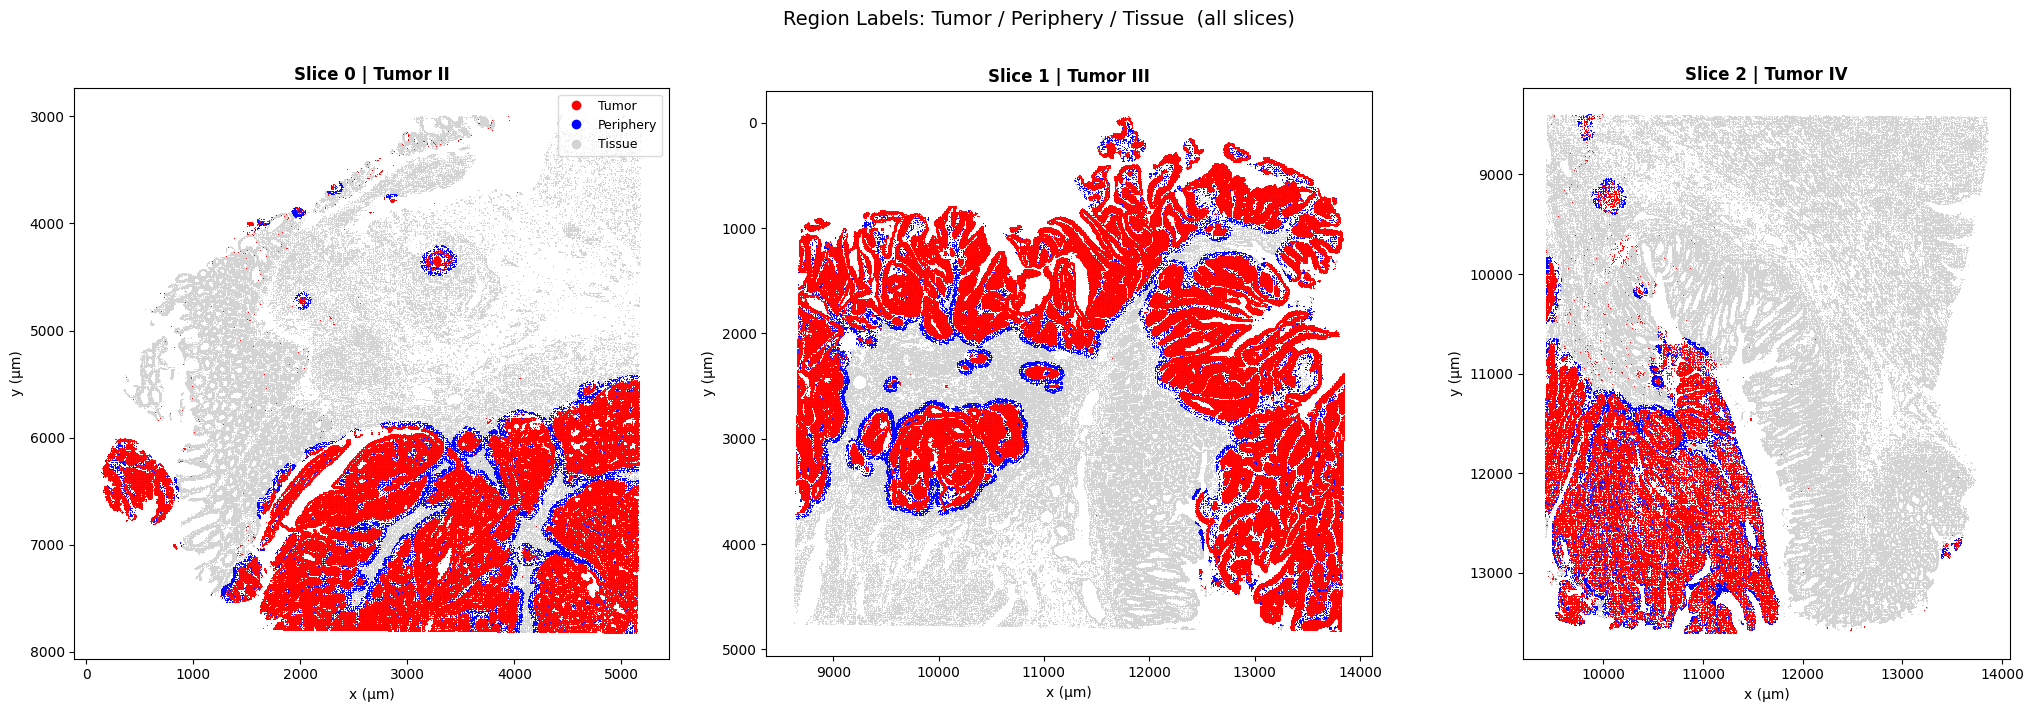

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

# --- Configuration ---
SLICE_CONFIGS = {
    0: "Tumor II",
    1: "Tumor III",
    2: "Tumor IV",
}

LABEL_COLORS = {
    "Tumor":     "red",
    "Periphery": "blue",
    "Tissue":    "lightgrey",
}

# --- Process each slice ---
results = {}

for slice_id, tumor_label in SLICE_CONFIGS.items():
    print(f"\n{'='*50}")
    print(f"Processing Slice {slice_id} | tumor label: '{tumor_label}'")

    sl = session.get_slice(slice_id)
    adata = sl.adata

    # Step 1: Select dominant label column
    if "DeconvolutionLabel1" in adata.obs.columns:
        label_col = adata.obs["DeconvolutionLabel1"]
        print(f"  Using column: DeconvolutionLabel1")
    else:
        label_col = adata.obs["celltype"]
        print(f"  Using column: celltype")

    # Step 1: tumor_mask
    tumor_mask = (label_col == tumor_label).values
    print(f"  Total spots:  {len(tumor_mask):,}")
    print(f"  Tumor spots:  {tumor_mask.sum():,}")

    # Step 2: Build cKDTree over ALL spot coords
    coords = adata.obs[["x", "y"]].values.astype(float)
    tree = cKDTree(coords)

    # Step 3: Seed filter — tumor spots with >= 25 OTHER tumor neighbors within 50 µm
    tumor_indices = np.where(tumor_mask)[0]
    tumor_coords  = coords[tumor_indices]

    # Query all tumor spots against full tree (r=50)
    neighbor_lists = tree.query_ball_point(tumor_coords, r=50)

    # Count how many returned neighbors are themselves tumor
    seed_flags = np.array([
        sum(1 for idx in nbrs if tumor_mask[idx]) >= 25
        for nbrs in neighbor_lists
    ])
    seed_tumor_indices = tumor_indices[seed_flags]
    seed_coords = coords[seed_tumor_indices]
    print(f"  Seed tumor spots (≥25 tumor neighbours in 50 µm): {len(seed_coords):,}")

    # Step 4: Periphery set — union of all spots within 50 µm of seeds, minus tumor spots
    if len(seed_coords) > 0:
        periphery_neighbor_lists = tree.query_ball_point(seed_coords, r=50)
        periphery_candidate_indices = set()
        for nbrs in periphery_neighbor_lists:
            periphery_candidate_indices.update(nbrs)
        # Remove any tumor spot from the periphery set
        tumor_index_set = set(tumor_indices.tolist())
        periphery_indices = periphery_candidate_indices - tumor_index_set
    else:
        periphery_indices = set()
    print(f"  Periphery spots: {len(periphery_indices):,}")

    # Step 5 & 6: Assign region_label
    region_label = np.full(len(adata), "Tissue", dtype=object)
    region_label[list(periphery_indices)] = "Periphery"
    region_label[tumor_mask]              = "Tumor"   # tumor overwrites periphery if any overlap

    adata.obs["region_label"] = pd.Categorical(
        region_label,
        categories=["Tumor", "Periphery", "Tissue"],
        ordered=False,
    )
    adata.uns["region_tumor_label"] = tumor_label

    # Step 7: Print counts
    counts = adata.obs["region_label"].value_counts().reindex(["Tumor", "Periphery", "Tissue"])
    print(f"\n  region_label counts:")
    for cat, cnt in counts.items():
        print(f"    {cat:<12}: {cnt:>10,}")

    results[slice_id] = {
        "adata":       adata,
        "tumor_label": tumor_label,
        "coords":      coords,
        "region_label": adata.obs["region_label"].values,
    }

# --- Figure: 1×3 panel ---
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, (slice_id, res) in zip(axes, results.items()):
    coords      = res["coords"]
    labels      = res["region_label"]
    tumor_label = res["tumor_label"]

    # Plot in order: Tissue first (background), then Periphery, then Tumor (foreground)
    for category in ["Tissue", "Periphery", "Tumor"]:
        mask = (labels == category)
        ax.scatter(
            coords[mask, 0],
            coords[mask, 1],
            c=LABEL_COLORS[category],
            s=0.5,
            linewidths=0,
            label=category,
            rasterized=True,
        )

    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(f"Slice {slice_id} | {tumor_label}", fontsize=12, fontweight="bold")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")

    # Legend (only on first panel to avoid repetition)
    if slice_id == 0:
        handles = [
            plt.Line2D([0], [0], marker="o", color="w",
                       markerfacecolor=LABEL_COLORS[c], markersize=8, label=c)
            for c in ["Tumor", "Periphery", "Tissue"]
        ]
        ax.legend(handles=handles, loc="upper right", fontsize=9, framealpha=0.7)

plt.suptitle("Region Labels: Tumor / Periphery / Tissue  (all slices)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

    slice_id patient     region       celltype        pct
0          0   P1CRC  Periphery      Adipocyte   0.000000
1          0   P1CRC     Tissue      Adipocyte   0.010131
2          0   P1CRC  Periphery            CAF  46.232226
3          0   P1CRC     Tissue            CAF  17.574947
4          0   P1CRC  Periphery     CD4 T cell   0.558402
5          0   P1CRC     Tissue     CD4 T cell   3.789145
6          0   P1CRC  Periphery     CD8 T cell   0.109378
7          0   P1CRC     Tissue     CD8 T cell   0.570398
8          0   P1CRC  Periphery    Endothelial  10.880203
9          0   P1CRC     Tissue    Endothelial   7.358439
10         0   P1CRC  Periphery  Enteric Glial   0.046054
11         0   P1CRC     Tissue  Enteric Glial   0.533925
12         0   P1CRC  Periphery     Enterocyte   0.869265
13         0   P1CRC     Tissue     Enterocyte   7.486095
14         0   P1CRC  Periphery     Epithelial   0.028784
15         0   P1CRC     Tissue     Epithelial   0.095235
16         0  

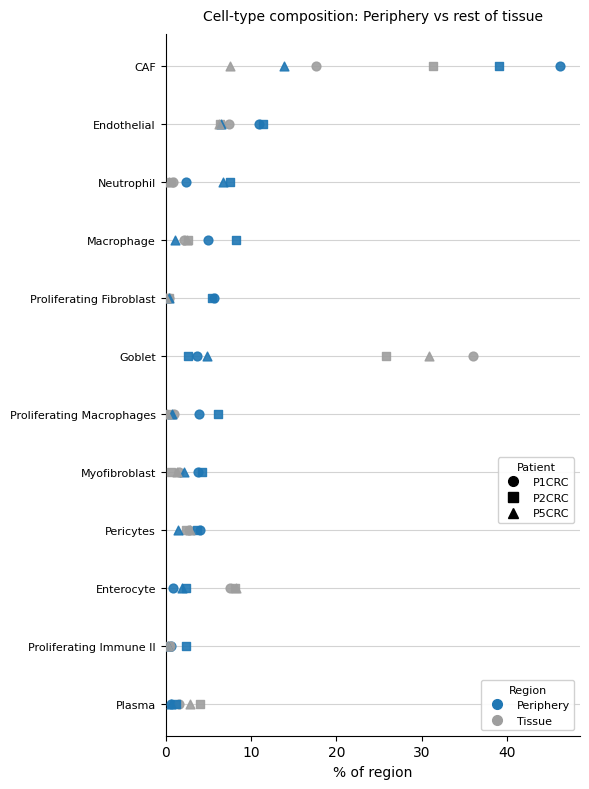

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# ── 1. Per-slice computation ──────────────────────────────────────────────────
patient_map = {0: "P1CRC", 1: "P2CRC", 2: "P5CRC"}
long_tables = []

for sid in [0, 1, 2]:
    sl = session.get_slice(sid)
    adata = sl.adata

    # Check region_label exists
    if 'region_label' not in adata.obs.columns:
        print(f"Slice {sid}: region_label missing — skipping")
        continue

    label = adata.obs['celltype'].astype(str)
    region = adata.obs['region_label'].astype(str)

    # 1. Contingency table: rows=region, cols=celltype
    ct = pd.crosstab(region, label)

    # Ensure row order
    for r in ["Tumor", "Periphery", "Tissue"]:
        if r not in ct.index:
            ct.loc[r] = 0
    ct = ct.loc[["Tumor", "Periphery", "Tissue"]]

    # 2. Row-normalize to 100 %
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    # 3. Drop Tumor row
    ct_pct = ct_pct.loc[["Periphery", "Tissue"]]

    # 4. Reshape to long format
    long = ct_pct.reset_index().melt(
        id_vars='region_label',
        var_name='celltype',
        value_name='pct'
    )
    long.rename(columns={'region_label': 'region'}, inplace=True)
    long['slice_id'] = sid
    long['patient'] = patient_map[sid]
    long = long[['slice_id', 'patient', 'region', 'celltype', 'pct']]
    long_tables.append(long)

comp_df = pd.concat(long_tables, ignore_index=True)
print(comp_df.head(20))

# ── 2. Store per-slice in adata.uns ──────────────────────────────────────────
for sid in [0, 1, 2]:
    sl = session.get_slice(sid)
    slice_rows = comp_df[comp_df['slice_id'] == sid].copy()
    sl.adata.uns['region_composition'] = slice_rows
print("\nStored region_composition in adata.uns for slices 0, 1, 2.")

# ── 3. Cell-type selection ────────────────────────────────────────────────────
# Max Periphery pct >= 1 % across patients, drop Tumor* labels
periph_df = comp_df[comp_df['region'] == 'Periphery']
max_periph = periph_df.groupby('celltype')['pct'].max()
keep_ct = max_periph[
    (max_periph >= 1.0) &
    (~max_periph.index.str.startswith("Tumor"))
].index.tolist()

plot_df = comp_df[comp_df['celltype'].isin(keep_ct)].copy()

# Order by mean Periphery pct descending (top = most enriched)
mean_periph = (
    periph_df[periph_df['celltype'].isin(keep_ct)]
    .groupby('celltype')['pct'].mean()
    .sort_values(ascending=True)   # ascending so top of y-axis = highest
)
ct_order = mean_periph.index.tolist()   # bottom -> top in y-axis

# ── 4. Plot ───────────────────────────────────────────────────────────────────
region_colors  = {"Periphery": "#1f77b4", "Tissue": "#9e9e9e"}
patient_markers = {"P1CRC": "o", "P2CRC": "s", "P5CRC": "^"}

fig, ax = plt.subplots(figsize=(6, 8))

# Light horizontal gridlines
for i, ct in enumerate(ct_order):
    ax.axhline(i, color='lightgrey', linewidth=0.8, zorder=0)

# Plot dots
for (patient, region), grp in plot_df.groupby(['patient', 'region']):
    color  = region_colors[region]
    marker = patient_markers[patient]
    y_vals = [ct_order.index(ct) for ct in grp['celltype'] if ct in ct_order]
    x_vals = [grp.loc[grp['celltype'] == ct, 'pct'].values[0]
               for ct in grp['celltype'] if ct in ct_order]
    ax.scatter(x_vals, y_vals,
               color=color, marker=marker,
               s=40, alpha=0.9, zorder=3,
               label=f"{region}|{patient}")

ax.set_yticks(range(len(ct_order)))
ax.set_yticklabels(ct_order, fontsize=8)
ax.set_xlabel("% of region", fontsize=10)
ax.set_title("Cell-type composition: Periphery vs rest of tissue", fontsize=10, pad=10)
ax.set_xlim(left=0)

# ── Legend: region (color) ────────────────────────────────────────────────────
legend_region = [
    mlines.Line2D([], [], color=c, marker='o', linestyle='None',
                  markersize=7, label=r)
    for r, c in region_colors.items()
]
# ── Legend: patient (shape) ───────────────────────────────────────────────────
legend_patient = [
    mlines.Line2D([], [], color='black', marker=m, linestyle='None',
                  markersize=7, label=p)
    for p, m in patient_markers.items()
]

leg1 = ax.legend(handles=legend_region,  title="Region",  loc='lower right',
                 fontsize=8, title_fontsize=8, framealpha=0.9)
ax.add_artist(leg1)
ax.legend(handles=legend_patient, title="Patient", loc='center right',
          fontsize=8, title_fontsize=8, framealpha=0.9,
          bbox_to_anchor=(1.0, 0.35))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


[Slice 0 | Tumor II]
  Periphery-Macrophage spots : 870
  Raw SPP1-only fraction     : 0.1264 (>= 0.05 → standard labeling)
  SPP1+  assigned            : 110
  SELENOP+ assigned          : 286
  Other (ambiguous/neither)  : 474
  macrophage_fallback_used   : False

[Slice 1 | Tumor III]
  Periphery-Macrophage spots : 1,895
  Raw SPP1-only fraction     : 0.5113 (>= 0.05 → standard labeling)
  SPP1+  assigned            : 969
  SELENOP+ assigned          : 370
  Other (ambiguous/neither)  : 556
  macrophage_fallback_used   : False

[Slice 2 | Tumor IV]
  Periphery-Macrophage spots : 197
  Raw SPP1-only fraction     : 0.0000 (< 0.05 → fallback triggered)
  SPP1+  assigned            : 0
  SELENOP+ assigned          : 131
  Other (ambiguous/neither)  : 66
  macrophage_fallback_used   : True



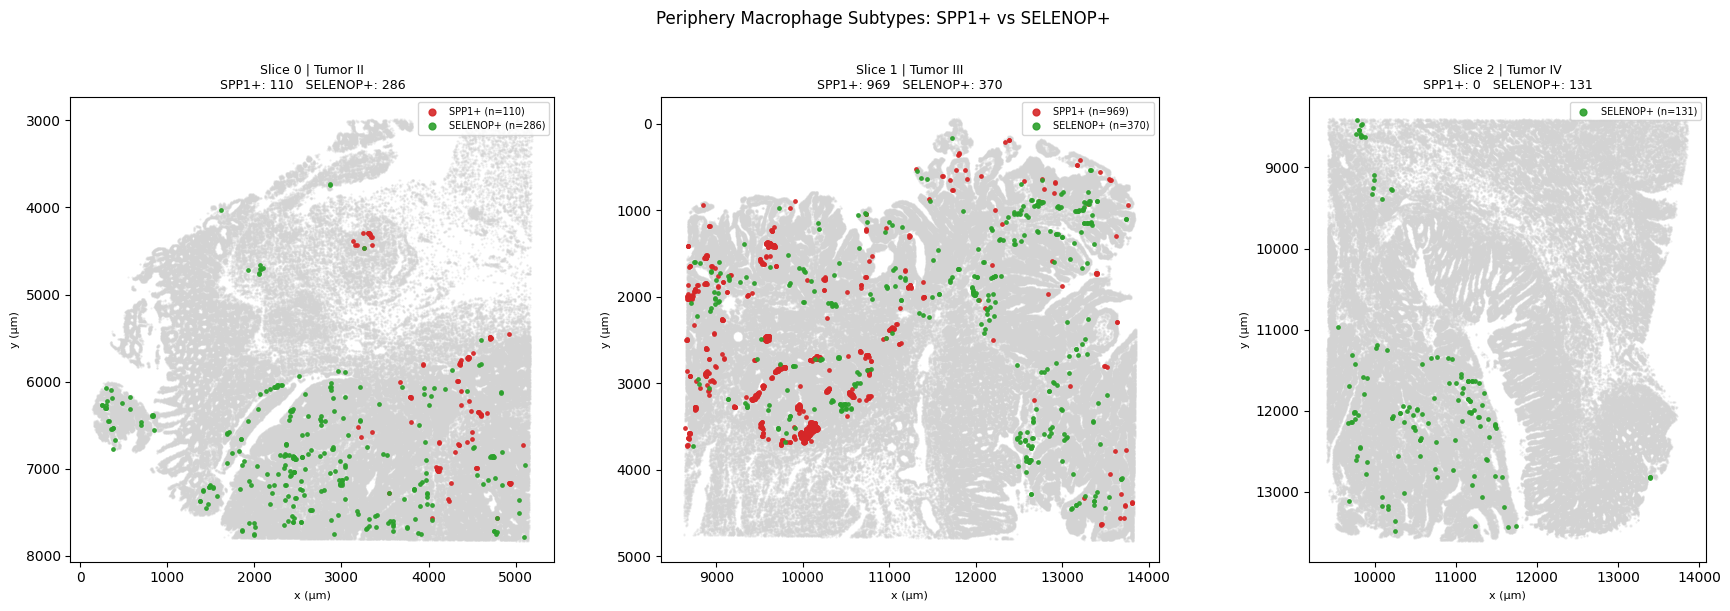

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

# ── Configuration ────────────────────────────────────────────────────────────
SLICE_IDS   = [0, 1, 2]
CATEGORIES  = ["SPP1+", "SELENOP+", "Other"]
COLORS      = {"SPP1+": "#d62728", "SELENOP+": "#2ca02c", "Other": "#cccccc"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for slice_id in SLICE_IDS:
    ax = axes[slice_id]
    slc = session.get_slice(slice_id)
    adata = slc.adata
    tumor_label = adata.uns.get('region_tumor_label', f'Tumor (slice {slice_id})')

    # ── Initialise output column ──────────────────────────────────────────────
    adata.obs['macrophage_subtype'] = pd.Categorical(
        ["Other"] * adata.n_obs,
        categories=CATEGORIES
    )
    adata.uns['macrophage_fallback_used'] = False

    # ── Background scatter (all spots) ───────────────────────────────────────
    ax.scatter(
        adata.obs['x'], adata.obs['y'],
        c='lightgrey', s=0.3, alpha=0.3, rasterized=True
    )

    # ── Build mac_idx ─────────────────────────────────────────────────────────
    periph_mask = adata.obs['region_label'] == "Periphery"
    mac_mask    = adata.obs['celltype']     == "Macrophage"
    mac_idx     = adata.obs.index[periph_mask & mac_mask]

    n_mac = len(mac_idx)
    has_spp1 = "SPP1"    in adata.var_names
    has_seln = "SELENOP" in adata.var_names

    # ── Skip guard ────────────────────────────────────────────────────────────
    if n_mac < 30 or not has_spp1:
        msg = (f"[Slice {slice_id}] SKIPPED — "
               f"mac_idx={n_mac}, SPP1 present={has_spp1}. "
               f"All spots set to 'Other'.")
        print(msg)
        ax.set_title(f"Slice {slice_id} | {tumor_label}\nSKIPPED", fontsize=9)
        ax.invert_yaxis(); ax.set_aspect('equal')
        continue

    # ── Extract raw counts for SPP1 and SELENOP ───────────────────────────────
    mac_pos = adata.obs.index.get_indexer(mac_idx)   # integer positions

    spp1_idx = adata.var_names.get_loc("SPP1")
    X_mac    = adata.X[mac_pos, :]

    if sp.issparse(X_mac):
        spp1_v = np.asarray(X_mac[:, spp1_idx].todense()).flatten()
    else:
        spp1_v = X_mac[:, spp1_idx].flatten()

    if has_seln:
        seln_idx = adata.var_names.get_loc("SELENOP")
        if sp.issparse(X_mac):
            seln_v = np.asarray(X_mac[:, seln_idx].todense()).flatten()
        else:
            seln_v = X_mac[:, seln_idx].flatten()
    else:
        print(f"[Slice {slice_id}] WARNING — SELENOP absent; all SELENOP masks will be False.")
        seln_v = np.zeros(n_mac, dtype=float)

    # ── Masks ─────────────────────────────────────────────────────────────────
    spp1_only_mask = (spp1_v > 0) & (seln_v == 0)
    seln_only_mask = (seln_v > 0) & (spp1_v == 0)
    both_mask      = (spp1_v > 0) & (seln_v > 0)

    # ── SPP1-only fraction gate ───────────────────────────────────────────────
    frac = spp1_only_mask.sum() / n_mac
    fallback = frac < 0.05
    adata.uns['macrophage_fallback_used'] = bool(fallback)

    # ── Build per-mac label array ─────────────────────────────────────────────
    mac_labels = np.full(n_mac, "Other", dtype=object)

    if fallback:
        # frac < 0.05 → no genuine SPP1+ population
        mac_labels[seln_only_mask | both_mask] = "SELENOP+"
        n_spp1_assigned = 0
        n_seln_assigned = int((seln_only_mask | both_mask).sum())
    else:
        mac_labels[spp1_only_mask] = "SPP1+"
        mac_labels[seln_only_mask] = "SELENOP+"
        # both_mask and neither remain "Other"
        n_spp1_assigned = int(spp1_only_mask.sum())
        n_seln_assigned = int(seln_only_mask.sum())

    # ── Write back to adata ───────────────────────────────────────────────────
    new_col = adata.obs['macrophage_subtype'].copy().astype(str)
    new_col.iloc[mac_pos] = mac_labels
    adata.obs['macrophage_subtype'] = pd.Categorical(new_col, categories=CATEGORIES)

    # ── Report ────────────────────────────────────────────────────────────────
    print(
        f"\n[Slice {slice_id} | {tumor_label}]\n"
        f"  Periphery-Macrophage spots : {n_mac:,}\n"
        f"  Raw SPP1-only fraction     : {frac:.4f} "
        f"({'< 0.05 → fallback triggered' if fallback else '>= 0.05 → standard labeling'})\n"
        f"  SPP1+  assigned            : {n_spp1_assigned:,}\n"
        f"  SELENOP+ assigned          : {n_seln_assigned:,}\n"
        f"  Other (ambiguous/neither)  : {n_mac - n_spp1_assigned - n_seln_assigned:,}\n"
        f"  macrophage_fallback_used   : {fallback}"
    )

    # ── Overlay macrophage subtypes ───────────────────────────────────────────
    for label, color in [("SPP1+", "#d62728"), ("SELENOP+", "#2ca02c")]:
        sub_mask = adata.obs['macrophage_subtype'] == label
        if sub_mask.sum() == 0:
            continue
        ax.scatter(
            adata.obs.loc[sub_mask, 'x'],
            adata.obs.loc[sub_mask, 'y'],
            c=color, s=6, alpha=0.9,
            label=f"{label} (n={sub_mask.sum():,})",
            rasterized=True
        )

    ax.set_title(
        f"Slice {slice_id} | {tumor_label}\n"
        f"SPP1+: {n_spp1_assigned:,}   SELENOP+: {n_seln_assigned:,}",
        fontsize=9
    )
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xlabel("x (µm)", fontsize=8)
    ax.set_ylabel("y (µm)", fontsize=8)
    ax.legend(fontsize=7, markerscale=2, loc='upper right')

plt.suptitle("Periphery Macrophage Subtypes: SPP1+ vs SELENOP+", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

mac_all.shape: (1866, 17939)

Crosstab subtype × patient:
patient   P1CRC  P2CRC  P5CRC
subtype                      
SELENOP+    286    370    131
SPP1+       110    969      0

Top 10 markers for SPP1+:
 names  logfoldchanges     pvals_adj
  SPP1       14.264460 1.834334e-294
 CHIT1        7.273333  2.653789e-07
CHI3L1        5.932371  1.302099e-20
 MARCO        5.114070  1.280111e-03
   LPL        4.698731  9.018156e-12
  MMP7        4.686712  4.080290e-03
   FN1        4.425208  5.329435e-30
  FBP1        4.164797  1.854315e-11
 IL1RN        4.039305  1.145679e-12
  OLR1        4.020336  3.239856e-02

Top 10 markers for SELENOP+:
   names  logfoldchanges     pvals_adj
 SELENOP       35.939434 1.834334e-294
   CD209        5.380187  4.625149e-06
DNASE1L3        5.294089  8.517563e-05
    PDK4        4.461435  4.808582e-03
   STAB1        4.250432  1.867561e-41
 SLC40A1        4.142607  1.044736e-34
  JCHAIN        4.045324  5.253177e-05
  MS4A6A        3.840227  1.537683e-33
   MPEG

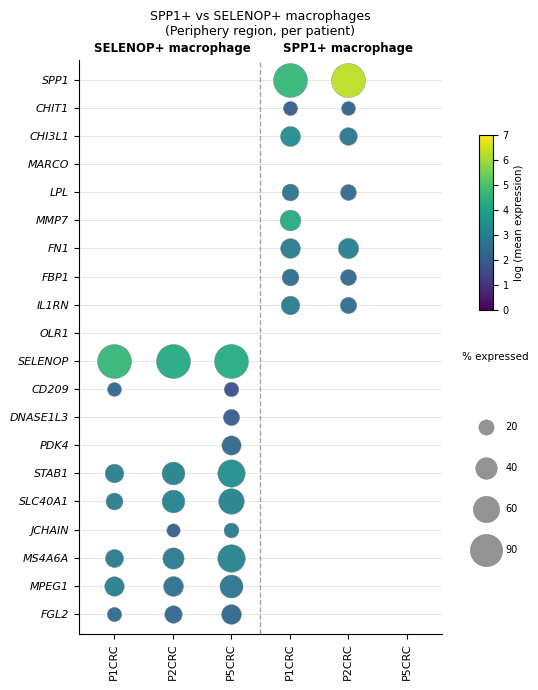

In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import matplotlib.colorbar
import warnings
warnings.filterwarnings('ignore')

# ── Step 1-2: Assemble combined object ────────────────────────────────────────
patient_map = {0: "P1CRC", 1: "P2CRC", 2: "P5CRC"}
subsets = []

for sid in [0, 1, 2]:
    sl = session.get_slice(sid)
    ad = sl.adata
    mask = ad.obs['macrophage_subtype'].isin(["SPP1+", "SELENOP+"])
    sub = ad[mask].copy()
    sub.obs['patient'] = patient_map[sid]
    sub.obs['subtype'] = sub.obs['macrophage_subtype'].astype(str)
    # Keep only needed obs cols
    sub.obs = sub.obs[['patient', 'subtype']].copy()
    subsets.append(sub)

mac_all = anndata.concat(subsets, join="inner", index_unique="-")
mac_all.obs['patient'] = mac_all.obs['patient'].astype('category')
mac_all.obs['subtype'] = mac_all.obs['subtype'].astype('category')

# ── Step 3: Shape and crosstab ─────────────────────────────────────────────────
print("mac_all.shape:", mac_all.shape)
print("\nCrosstab subtype × patient:")
print(pd.crosstab(mac_all.obs['subtype'], mac_all.obs['patient']))

# ── Steps 4-6: Normalize, log1p, save lognorm layer ───────────────────────────
sc.pp.normalize_total(mac_all, target_sum=1e4)
sc.pp.log1p(mac_all)
import scipy.sparse as sp
if sp.issparse(mac_all.X):
    mac_all.layers['lognorm'] = mac_all.X.copy()
else:
    mac_all.layers['lognorm'] = mac_all.X.copy()

# ── Step 7: DE ────────────────────────────────────────────────────────────────
sc.tl.rank_genes_groups(mac_all, groupby="subtype", method="wilcoxon",
                        pts=True, use_raw=False, n_genes=200)

# ── Step 8: Pull top markers ───────────────────────────────────────────────────
de_df = sc.get.rank_genes_groups_df(mac_all, group=None)

top_genes_by_group = {}
for grp in ["SPP1+", "SELENOP+"]:
    g_df = de_df[(de_df['group'] == grp) &
                 (de_df['pvals_adj'] < 0.05) &
                 (de_df['logfoldchanges'] > 0.1)].copy()
    g_df = g_df.sort_values('logfoldchanges', ascending=False).head(10)
    top_genes_by_group[grp] = g_df['names'].tolist()
    print(f"\nTop 10 markers for {grp}:")
    print(g_df[['names','logfoldchanges','pvals_adj']].to_string(index=False))

# Deduplicate: SPP1+ first, then SELENOP+, preserving order
seen = []
for g in top_genes_by_group["SPP1+"] + top_genes_by_group["SELENOP+"]:
    if g not in seen:
        seen.append(g)
marker_genes = seen
print(f"\nFinal marker_genes ({len(marker_genes)}): {marker_genes}")

# ── Step 9: Per (subtype × patient) dot statistics ────────────────────────────
lognorm = mac_all.layers['lognorm']
if sp.issparse(lognorm):
    lognorm_dense = lognorm.toarray()
else:
    lognorm_dense = np.array(lognorm)

gene_names = mac_all.var_names.tolist()
gene_idx = {g: gene_names.index(g) for g in marker_genes if g in gene_names}
missing = [g for g in marker_genes if g not in gene_names]
if missing:
    print(f"Warning: genes not found in var_names: {missing}")
    marker_genes = [g for g in marker_genes if g in gene_names]

rows = []
for grp in ["SELENOP+", "SPP1+"]:
    for pat in ["P1CRC", "P2CRC", "P5CRC"]:
        mask = ((mac_all.obs['subtype'] == grp) &
                (mac_all.obs['patient'] == pat)).values
        n = mask.sum()
        if n == 0:
            print(f"  Skipping {grp} × {pat}: 0 spots")
            continue
        mat = lognorm_dense[mask, :]
        for gene in marker_genes:
            gi = gene_idx[gene]
            vals = mat[:, gi]
            pct_expr = 100.0 * (vals > 0).mean()
            mean_expr = np.expm1(vals).mean()
            log_mean = np.log1p(mean_expr)
            rows.append({'gene': gene, 'group': grp, 'patient': pat,
                         'pct_expressed': pct_expr, 'log_mean_expr': log_mean})

dot_df = pd.DataFrame(rows)

# ── Step 10: pct_expressed filter ─────────────────────────────────────────────
dot_df = dot_df[dot_df['pct_expressed'] >= 15].copy()
print(f"\ndot_df shape after pct filter: {dot_df.shape}")

# ── Step 11: Gene ordering (SPP1+ block first, then SELENOP+) ─────────────────
spp1_top10  = top_genes_by_group["SPP1+"]
seln_top10  = top_genes_by_group["SELENOP+"]
spp1_set    = set(spp1_top10)
seln_set    = set(seln_top10)

spp1_only  = [g for g in spp1_top10 if g not in seln_set  and g in marker_genes]
shared_    = [g for g in spp1_top10 if g in seln_set      and g in marker_genes]
seln_only  = [g for g in seln_top10 if g not in spp1_set  and g in marker_genes]
gene_order = []
for g in spp1_only + shared_ + seln_only:
    if g not in gene_order:
        gene_order.append(g)
# Add any remaining marker_genes not yet placed
for g in marker_genes:
    if g not in gene_order:
        gene_order.append(g)

print(f"\nGene order for plot ({len(gene_order)}): {gene_order}")

# ── Step 12-13: Plot ──────────────────────────────────────────────────────────
col_order = [
    ("SELENOP+", "P1CRC"), ("SELENOP+", "P2CRC"), ("SELENOP+", "P5CRC"),
    ("SPP1+",    "P1CRC"), ("SPP1+",    "P2CRC"), ("SPP1+",    "P5CRC"),
]
col_labels   = ["P1CRC", "P2CRC", "P5CRC", "P1CRC", "P2CRC", "P5CRC"]
col_to_x     = {col: i for i, col in enumerate(col_order)}

fig, ax = plt.subplots(figsize=(5.5, 7))

# Draw dots
for _, row in dot_df.iterrows():
    key = (row['group'], row['patient'])
    if key not in col_to_x:
        continue
    xi = col_to_x[key]
    yi = gene_order.index(row['gene']) if row['gene'] in gene_order else None
    if yi is None:
        continue
    sc_plot = ax.scatter(xi, yi,
                         s=row['pct_expressed'] * 6,
                         c=[[row['log_mean_expr']]],
                         cmap='viridis', vmin=0, vmax=7,
                         alpha=0.95, linewidths=0.3, edgecolors='grey')

# Axes formatting
ax.set_xticks(range(len(col_order)))
ax.set_xticklabels(col_labels, rotation=90, fontsize=8)
ax.set_yticks(range(len(gene_order)))
ax.set_yticklabels(gene_order, fontstyle='italic', fontsize=8)
ax.set_xlim(-0.6, len(col_order) - 0.4)
ax.set_ylim(-0.7, len(gene_order) - 0.3)
ax.invert_yaxis()

# Vertical dashed separator between SELENOP+ and SPP1+ blocks
ax.axvline(x=2.5, color='grey', linestyle='--', linewidth=1.0, alpha=0.7)

# Light horizontal gridlines
for yi in range(len(gene_order)):
    ax.axhline(y=yi, color='lightgrey', linewidth=0.4, zorder=0)

# Top-axis group labels
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks([1.0, 4.0])
ax2.set_xticklabels(["SELENOP+ macrophage", "SPP1+ macrophage"], fontsize=8.5, fontweight='bold')
ax2.tick_params(length=0)
ax2.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

# Hide top/right spines on main ax
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ── Colorbar ──────────────────────────────────────────────────────────────────
sm = plt.cm.ScalarMappable(cmap='viridis',
                            norm=plt.Normalize(vmin=0, vmax=7))
sm.set_array([])
cbar_ax = fig.add_axes([0.88, 0.55, 0.025, 0.25])
cb = fig.colorbar(sm, cax=cbar_ax)
cb.set_label('log (mean expression)', fontsize=7.5)
cb.ax.tick_params(labelsize=7)

# ── Size legend ───────────────────────────────────────────────────────────────
size_ax = fig.add_axes([0.85, 0.12, 0.12, 0.35])
size_ax.set_xlim(0, 1)
size_ax.set_ylim(-1, 5)
size_ax.axis('off')
size_ax.set_title('% expressed', fontsize=7.5, pad=4)
for i, pct in enumerate([20, 40, 60, 90]):
    size_ax.scatter(0.35, 3.5 - i,
                    s=pct * 6, color='grey', alpha=0.85,
                    edgecolors='grey', linewidths=0.4)
    size_ax.text(0.65, 3.5 - i, str(pct), va='center', fontsize=7)

ax.set_title("SPP1+ vs SELENOP+ macrophages\n(Periphery region, per patient)",
             fontsize=9, pad=18)

plt.tight_layout(rect=[0, 0, 0.84, 1])

# ── Store results on each slice ───────────────────────────────────────────────
for sid in [0, 1, 2]:
    sl = session.get_slice(sid)
    sl.adata.uns['macrophage_subtype_de']    = dot_df.copy()
    sl.adata.uns['macrophage_marker_genes']  = marker_genes

plt.show()
print("\nStored dot_df -> adata.uns['macrophage_subtype_de'] on slices 0, 1, 2")
print("Stored marker_genes -> adata.uns['macrophage_marker_genes'] on slices 0, 1, 2")

Slice 0 (P1CRC): 396 macrophage spots   SPP1+=110  SELENOP+=286
Slice 1 (P2CRC): 1339 macrophage spots   SPP1+=969  SELENOP+=370
Slice 2 (P5CRC): 131 macrophage spots   SPP1+=0  SELENOP+=131

mac_all shape: (1866, 17939)
patient   P1CRC  P2CRC  P5CRC
subtype                      
SELENOP+    286    370    131
SPP1+       110    969      0

After gene filter (min_cells=93): 1021 genes

SPP1+    top-250 markers (lfc>0.1): 250
SELENOP+ top-250 markers (lfc>0.1): 250

SPP1+    top 20: ['SPP1', 'CHIT1', 'CHI3L1', 'TM4SF19', 'MARCO', 'LPL', 'MMP7', 'FN1', 'FBP1', 'IL1RN', 'OLR1', 'CYP27A1', 'APOC1', 'CSTB', 'SLC11A1', 'MMP9', 'APOE', 'CD52', 'IFI6', 'CD9']
SELENOP+ top 20: ['SELENOP', 'CD209', 'DNASE1L3', 'PDK4', 'STAB1', 'SLC40A1', 'JCHAIN', 'MS4A6A', 'MPEG1', 'CD74', 'FGL2', 'C1QC', 'CXCL14', 'SIGLEC10', 'CCL24', 'F3', 'ENPP2', 'IGKC', 'ITGA4', 'C1QA']

Stored enrichment_genes_groups on slice 0.

MSigDB_Hallmark_2020: 50 gene sets after size filter
[SPP1+] overlap=151/250  raw P<1e-3: 18  

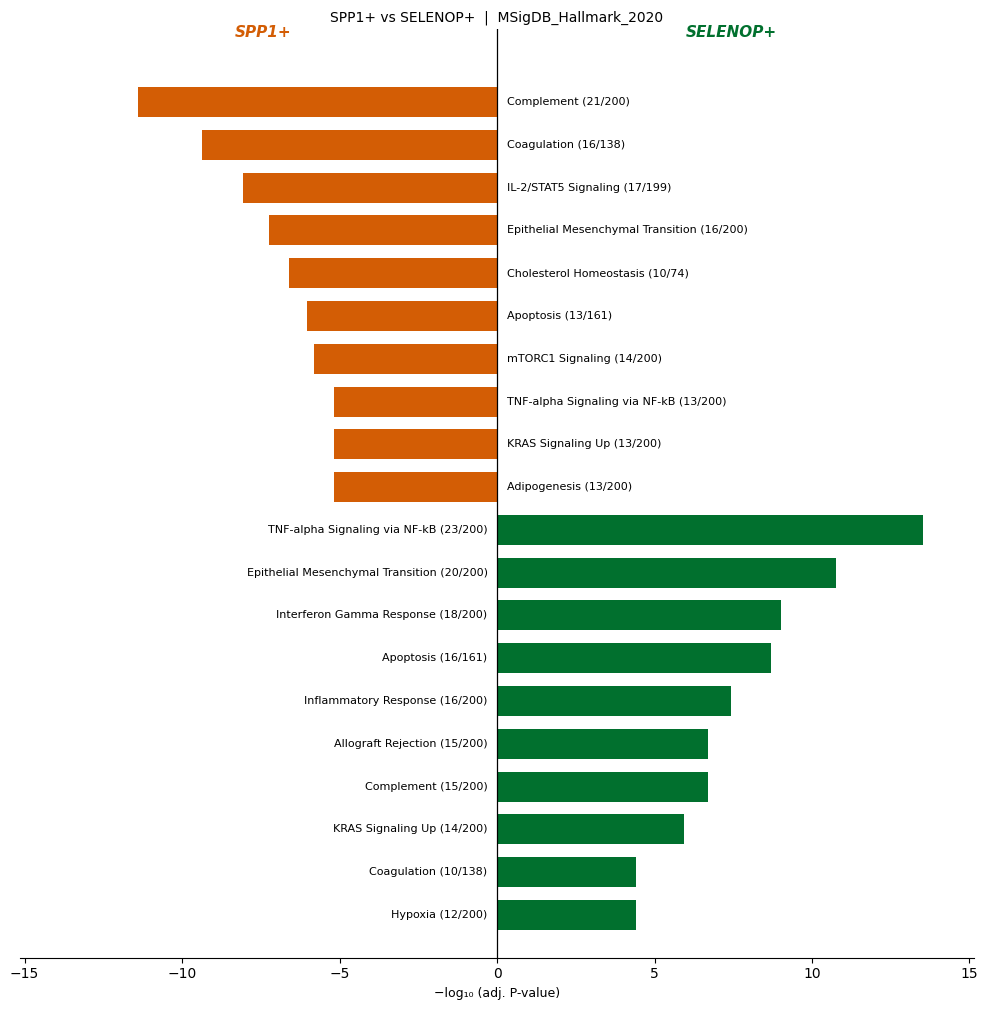

In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import gseapy as gp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# STEP 1 – Assemble pooled macrophage object
# ─────────────────────────────────────────────
patient_map = {0: "P1CRC", 1: "P2CRC", 2: "P5CRC"}
subsets = []

for sid in [0, 1, 2]:
    sl = session.get_slice(sid)
    ad = sl.adata
    mask = ad.obs['macrophage_subtype'].isin(["SPP1+", "SELENOP+"])
    sub = ad[mask].copy()
    sub.obs['subtype'] = sub.obs['macrophage_subtype'].astype(str)
    sub.obs['patient'] = patient_map[sid]
    subsets.append(sub)
    print(f"Slice {sid} ({patient_map[sid]}): {mask.sum()} macrophage spots "
          f"  SPP1+={int((sub.obs['subtype']=='SPP1+').sum())}  "
          f"SELENOP+={int((sub.obs['subtype']=='SELENOP+').sum())}")

mac_all = anndata.concat(subsets, join="inner", index_unique="-")
mac_all.obs = mac_all.obs[['subtype', 'patient']]
print(f"\nmac_all shape: {mac_all.shape}")
print(pd.crosstab(mac_all.obs['subtype'], mac_all.obs['patient']))

# ─────────────────────────────────────────────
# STEP 2 – Preprocess
# ─────────────────────────────────────────────
n_obs = mac_all.n_obs
min_cells = max(3, int(0.05 * n_obs))
sc.pp.filter_genes(mac_all, min_cells=min_cells)
print(f"\nAfter gene filter (min_cells={min_cells}): {mac_all.n_vars} genes")

sc.pp.normalize_total(mac_all, target_sum=1e4)
sc.pp.log1p(mac_all)
mac_all.layers['lognorm'] = mac_all.X.copy()

# ─────────────────────────────────────────────
# STEP 3 – Differential expression
# ─────────────────────────────────────────────
sc.tl.rank_genes_groups(
    mac_all, groupby='subtype', method='wilcoxon',
    pts=True, layer='lognorm', use_raw=False
)

def extract_markers(adata, group, top_n=250, lfc_min=0.1):
    rgg = adata.uns['rank_genes_groups']
    genes  = rgg['names'][group]
    lfc    = rgg['logfoldchanges'][group]
    pvals  = rgg['pvals_adj'][group]
    df = pd.DataFrame({'gene': genes, 'lfc': lfc, 'padj': pvals})
    df = df[df['lfc'] > lfc_min].sort_values('lfc', ascending=False)
    return df.head(top_n)['gene'].tolist()

spp1_markers    = extract_markers(mac_all, 'SPP1+')
selenop_markers = extract_markers(mac_all, 'SELENOP+')

print(f"\nSPP1+    top-250 markers (lfc>0.1): {len(spp1_markers)}")
print(f"SELENOP+ top-250 markers (lfc>0.1): {len(selenop_markers)}")
print(f"\nSPP1+    top 20: {spp1_markers[:20]}")
print(f"SELENOP+ top 20: {selenop_markers[:20]}")

# ─────────────────────────────────────────────
# STEP 4 – Store on slice 0
# ─────────────────────────────────────────────
slice0 = session.get_slice(0)
slice0.adata.uns['enrichment_genes_groups'] = {
    "SPP1+":    spp1_markers,
    "SELENOP+": selenop_markers,
}
print("\nStored enrichment_genes_groups on slice 0.")

# ─────────────────────────────────────────────
# STEP 5 – Pathway enrichment
# ─────────────────────────────────────────────
adata = slice0.adata
groups = {g: list(v) for g, v in adata.uns['enrichment_genes_groups'].items()}
group_names = list(groups.keys())   # ["SPP1+", "SELENOP+"]
species = 'human'
library = 'MSigDB_Hallmark_2020'

organism = 'Human'
gene_sets = gp.get_library(library, organism=organism)
min_size, max_size = 10, 500
gene_sets_filtered = {
    n: g for n, g in gene_sets.items()
    if min_size <= len(g) <= max_size
}
print(f"\n{library}: {len(gene_sets_filtered)} gene sets after size filter")

library_genes = set()
for gs in gene_sets_filtered.values():
    library_genes.update(gs)

results_by_group = {}
for group_name, gene_list in groups.items():
    overlap = set(gene_list) & library_genes
    if len(overlap) < len(gene_list) * 0.3:
        upper = [g.upper() for g in gene_list]
        if len(set(upper) & library_genes) > len(overlap):
            gene_list = upper
            overlap = set(upper) & library_genes
    if len(overlap) < 2:
        print(f"[{group_name}] only {len(overlap)} genes map to library — skipping")
        results_by_group[group_name] = pd.DataFrame()
        continue
    try:
        enr = gp.enrichr(
            gene_list=gene_list, gene_sets=library,
            organism=species, outdir=None, no_plot=True,
        )
    except Exception as e:
        print(f"  Enrichr API unavailable ({e}), falling back to local test")
        enr = gp.enrich(
            gene_list=gene_list, gene_sets=gene_sets_filtered,
            outdir=None, no_plot=True, verbose=False,
        )
    df = enr.results.copy()
    df['group'] = group_name
    df['hit']      = df['Overlap'].astype(str).str.split('/').str[0].astype(int)
    df['set_size'] = df['Overlap'].astype(str).str.split('/').str[1].astype(int)
    df['neg_log10_padj'] = -np.log10(df['Adjusted P-value'].clip(lower=1e-50))
    results_by_group[group_name] = df
    print(f"[{group_name}] overlap={len(overlap)}/{len(gene_list)}  "
          f"raw P<1e-3: {int((df['P-value']<1e-3).sum())}  "
          f"FDR<0.05:  {int((df['Adjusted P-value']<0.05).sum())}")

# Store results
adata.uns['enrichment_results_groups'] = results_by_group
adata.uns['enrichment_params'] = {
    'group_names': group_names, 'species': species,
    'library': library, 'min_size': min_size, 'max_size': max_size,
    'background_size': len(adata.var_names),
}

for group_name, df in results_by_group.items():
    print(f"\nTop 10 {group_name} terms:")
    if len(df) == 0:
        print("  (none)"); continue
    for _, row in df.sort_values('P-value').head(10).iterrows():
        print(f"  {row['Term'][:55]:55s}  P={row['P-value']:.1e}  "
              f"padj={row['Adjusted P-value']:.1e}  hit={row['Overlap']}")

# ─────────────────────────────────────────────
# STEP 6 – Mirrored bar plot
# ─────────────────────────────────────────────
p_threshold  = 1e-3
top_n        = 10
left_name    = "SPP1+"       # left (orange)
right_name   = "SELENOP+"   # right (green)
left_color   = "#D35D05"
right_color  = "#01702E"

def _top(df, n):
    if len(df) == 0:
        return df
    d = df[df['P-value'] < p_threshold].copy()
    return d.sort_values('neg_log10_padj', ascending=False).head(n)

left_df  = _top(results_by_group[left_name],  top_n)
right_df = _top(results_by_group[right_name], top_n)

if len(left_df) == 0 and len(right_df) == 0:
    print("No terms pass the p-value threshold — nothing to plot.")
else:
    left_df  = left_df.assign(signed=-left_df['neg_log10_padj'],  side=left_name)
    right_df = right_df.assign(signed=right_df['neg_log10_padj'], side=right_name)

    # Sort within each block: shortest bar at bottom of block
    ldf = left_df.sort_values('neg_log10_padj', ascending=True).reset_index(drop=True)
    rdf = right_df.sort_values('neg_log10_padj', ascending=True).reset_index(drop=True)
    n_l, n_r = len(ldf), len(rdf)
    n_total  = n_l + n_r

    fig, ax = plt.subplots(figsize=(10, max(5, 0.42 * n_total + 1.8)))

    # Right block (SELENOP+, positive x) at y-positions 0 .. n_r-1
    for i, (_, row) in enumerate(rdf.iterrows()):
        ax.barh(i, row['neg_log10_padj'], color=right_color, edgecolor='none', height=0.7)

    # Left block (SPP1+, negative x) at y-positions n_r .. n_total-1
    for i, (_, row) in enumerate(ldf.iterrows()):
        ax.barh(n_r + i, -row['neg_log10_padj'], color=left_color, edgecolor='none', height=0.7)

    ax.axvline(0, color='black', linewidth=0.9)
    ax.set_yticks([])

    xmax = max(
        rdf['neg_log10_padj'].max() if n_r > 0 else 1,
        ldf['neg_log10_padj'].max() if n_l > 0 else 1,
    )
    ax.set_xlim(-xmax * 1.12, xmax * 1.12)
    ax.set_ylim(-1.0, n_total + 0.7)

    # Labels on the OPPOSITE blank side from their bars
    for i, (_, row) in enumerate(rdf.iterrows()):           # right bars → label left
        label = f"{row['Term']} ({row['hit']}/{row['set_size']})"
        ax.text(-0.3, i, label, ha='right', va='center', fontsize=8)
    for i, (_, row) in enumerate(ldf.iterrows()):           # left bars  → label right
        label = f"{row['Term']} ({row['hit']}/{row['set_size']})"
        ax.text(0.3, n_r + i, label, ha='left', va='center', fontsize=8)

    # Group name headers
    ax.text(-xmax * 0.55, n_total + 0.45, left_name,  ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=left_color,  fontstyle='italic')
    ax.text( xmax * 0.55, n_total + 0.45, right_name, ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=right_color, fontstyle='italic')

    ax.set_xlabel('−log₁₀ (adj. P-value)', fontsize=9)
    ax.set_title(f"{left_name} vs {right_name}  |  {library}", fontsize=10)
    for side in ('left', 'right', 'top'):
        ax.spines[side].set_visible(False)

    plt.tight_layout()
    plt.show()


Slice 0 | P1CRC | tumor label: Tumor II

  ── Subtype: SPP1+ ──
    Macrophage spots: 110
    KDE peak: (4464.5, 6035.8)
    Spots within 350 µm of peak: 7431
    Tumor spots in region: 6464
    Tumor spots ≤50 µm from macrophage: 543
    ✓ Collected 543 tumor spots → niche=SPP1, patient=P1CRC

  ── Subtype: SELENOP+ ──
    Macrophage spots: 286
    KDE peak: (2520.5, 7007.6)
    Spots within 350 µm of peak: 7313
    Tumor spots in region: 5338
    Tumor spots ≤50 µm from macrophage: 2003
    ✓ Collected 2003 tumor spots → niche=SELENOP, patient=P1CRC

Slice 1 | P2CRC | tumor label: Tumor III

  ── Subtype: SPP1+ ──
    Macrophage spots: 969
    KDE peak: (10043.4, 3495.5)
    Spots within 350 µm of peak: 6780
    Tumor spots in region: 4724
    Tumor spots ≤50 µm from macrophage: 1192
    ✓ Collected 1192 tumor spots → niche=SPP1, patient=P2CRC

  ── Subtype: SELENOP+ ──
    Macrophage spots: 370
    KDE peak: (12853.3, 1091.2)
    Spots within 350 µm of peak: 5602
    Tumor spots in

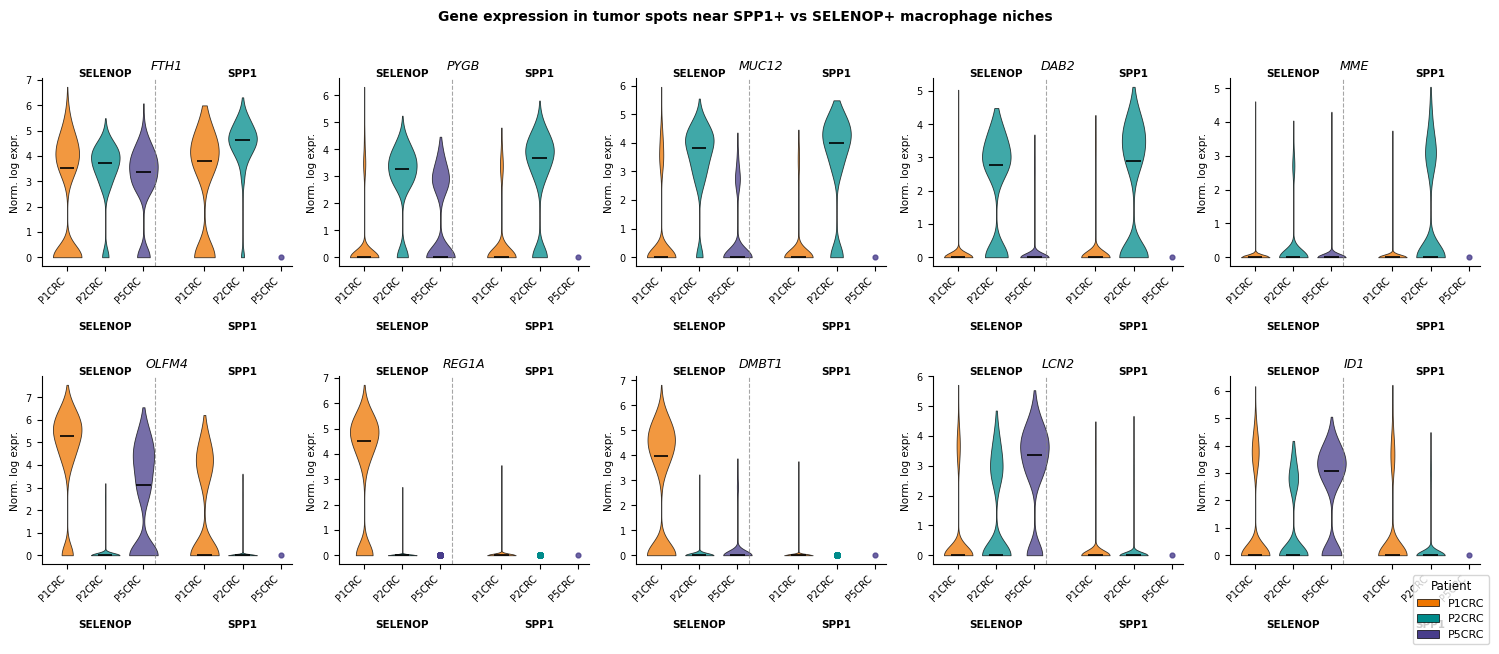

In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import gaussian_kde
from scipy.spatial import cKDTree
import warnings
warnings.filterwarnings('ignore')

# ── Patient labels ──────────────────────────────────────────────────────────
PATIENT_MAP = {0: "P1CRC", 1: "P2CRC", 2: "P5CRC"}
PATIENT_COLORS = {"P1CRC": "#EE7600", "P2CRC": "#008B8B", "P5CRC": "#483D8B"}
SUBTYPES = ["SPP1+", "SELENOP+"]
SUBTYPE_LABEL_MAP = {"SPP1+": "SPP1", "SELENOP+": "SELENOP"}

RADIUS_NICHE  = 350   # µm – region around KDE peak
RADIUS_TOUCH  = 50    # µm – tumor-to-macrophage proximity

subset_list = []   # will collect (slice_id, subtype, AnnData subset)

# ════════════════════════════════════════════════════════════════════════════
# STEP 1-5 : per slice, per subtype
# ════════════════════════════════════════════════════════════════════════════
for slice_id in [0, 1, 2]:
    sl = session.get_slice(slice_id)
    adata = sl.adata
    patient = PATIENT_MAP[slice_id]
    tumor_label = adata.uns.get('region_tumor_label', None)

    print(f"\n{'='*60}")
    print(f"Slice {slice_id} | {patient} | tumor label: {tumor_label}")

    # coordinates (all spots)
    all_x = adata.obs['x'].values.astype(float)
    all_y = adata.obs['y'].values.astype(float)
    all_coords = np.column_stack([all_x, all_y])

    for subtype in SUBTYPES:
        subtype_label = SUBTYPE_LABEL_MAP[subtype]
        print(f"\n  ── Subtype: {subtype} ──")

        # ── Step 1: macrophage spots of this subtype ─────────────────────
        mac_mask = adata.obs['macrophage_subtype'] == subtype
        mac_idx  = np.where(mac_mask)[0]

        if len(mac_idx) < 5:
            print(f"    SKIP: only {len(mac_idx)} spots")
            continue

        mac_coords = all_coords[mac_idx]   # (n_mac, 2)
        print(f"    Macrophage spots: {len(mac_idx)}")

        # ── Step 2: KDE peak on 200×200 grid ─────────────────────────────
        xmin, xmax = mac_coords[:, 0].min(), mac_coords[:, 0].max()
        ymin, ymax = mac_coords[:, 1].min(), mac_coords[:, 1].max()

        # small jitter guard if coordinates are degenerate
        if xmax - xmin < 1: xmax = xmin + 1
        if ymax - ymin < 1: ymax = ymin + 1

        grid_x = np.linspace(xmin, xmax, 200)
        grid_y = np.linspace(ymin, ymax, 200)
        gx, gy  = np.meshgrid(grid_x, grid_y)
        grid_pts = np.vstack([gx.ravel(), gy.ravel()])   # (2, 40000)

        kde = gaussian_kde(mac_coords.T)
        density = kde(grid_pts).reshape(200, 200)

        peak_flat = np.argmax(density)
        peak_row, peak_col = np.unravel_index(peak_flat, (200, 200))
        peak = np.array([grid_x[peak_col], grid_y[peak_row]])
        print(f"    KDE peak: ({peak[0]:.1f}, {peak[1]:.1f})")

        # ── Step 3: all spots within 350 µm of peak ──────────────────────
        dist_all = np.linalg.norm(all_coords - peak, axis=1)
        region_mask = dist_all <= RADIUS_NICHE
        region_idx  = np.where(region_mask)[0]
        print(f"    Spots within {RADIUS_NICHE} µm of peak: {len(region_idx)}")

        if len(region_idx) == 0:
            print(f"    SKIP: no spots in region")
            continue

        # ── Step 4: tumor spots ≤50 µm from a region macrophage ──────────
        # macrophage spots within the 350 µm region
        region_mac_mask = region_mask & mac_mask
        region_mac_idx  = np.where(region_mac_mask)[0]

        if len(region_mac_idx) == 0:
            print(f"    SKIP: no macrophage spots in region")
            continue

        region_mac_coords = all_coords[region_mac_idx]

        # tumor spots in the region
        if tumor_label is None:
            print(f"    SKIP: no tumor label in uns")
            continue

        region_tumor_mask = (
            region_mask &
            (adata.obs['celltype'] == tumor_label)
        )
        region_tumor_idx = np.where(region_tumor_mask)[0]
        print(f"    Tumor spots in region: {len(region_tumor_idx)}")

        if len(region_tumor_idx) == 0:
            print(f"    SKIP: no tumor spots in region")
            continue

        region_tumor_coords = all_coords[region_tumor_idx]

        # cKDTree: which tumor spots are ≤50 µm from any region macrophage?
        mac_tree  = cKDTree(region_mac_coords)
        close_ids = mac_tree.query_ball_point(region_tumor_coords, r=RADIUS_TOUCH)
        near_mask = np.array([len(c) > 0 for c in close_ids])
        near_tumor_idx = region_tumor_idx[near_mask]
        print(f"    Tumor spots ≤{RADIUS_TOUCH} µm from macrophage: {len(near_tumor_idx)}")

        if len(near_tumor_idx) == 0:
            print(f"    SKIP: no tumor spots near macrophage")
            continue

        # ── Step 5: label and collect ─────────────────────────────────────
        sub = adata[near_tumor_idx].copy()
        sub.obs['CellType'] = subtype_label
        sub.obs['Patient']  = patient
        sub.obs['CellType'] = sub.obs['CellType'].astype(str)
        sub.obs['Patient']  = sub.obs['Patient'].astype(str)
        subset_list.append(sub)
        print(f"    ✓ Collected {len(near_tumor_idx)} tumor spots → niche={subtype_label}, patient={patient}")

print(f"\n{'='*60}")
print(f"Total (slice, subtype) pairs collected: {len(subset_list)}")

# ════════════════════════════════════════════════════════════════════════════
# STEP 6-9 : merge, filter, normalize, DE
# ════════════════════════════════════════════════════════════════════════════
if len(subset_list) < 2:
    print("ERROR: fewer than 2 subsets — cannot run DE.")
else:
    # ── Step 6: concatenate ───────────────────────────────────────────────
    mac_all = anndata.concat(subset_list, join="inner", index_unique="-")
    # keep only needed obs columns
    mac_all.obs = mac_all.obs[['CellType', 'Patient']].copy()
    print(f"\nmac_all shape: {mac_all.shape}")
    print("\nCrosstab CellType × Patient:")
    print(pd.crosstab(mac_all.obs['CellType'], mac_all.obs['Patient']))

    # check how many unique CellType groups we have
    unique_groups = mac_all.obs['CellType'].unique().tolist()
    print(f"\nUnique CellType groups: {unique_groups}")

    if len(unique_groups) < 2:
        print("WARNING: only one CellType group present — DE requires two groups.")
        print("Proceeding but results may be limited.")

    # ── Step 7: remove MT genes ───────────────────────────────────────────
    non_mt = ~mac_all.var_names.str.startswith("MT-")
    mac_all = mac_all[:, non_mt].copy()
    print(f"\nAfter MT- removal: {mac_all.shape}")

    # ── Step 8: filter genes, normalize, log1p ────────────────────────────
    n_obs = mac_all.n_obs
    min_cells = max(3, int(0.05 * n_obs))
    sc.pp.filter_genes(mac_all, min_cells=min_cells)
    print(f"After filter_genes (min_cells={min_cells}): {mac_all.shape}")

    sc.pp.normalize_total(mac_all, target_sum=1e4)
    sc.pp.log1p(mac_all)
    mac_all.layers['lognorm'] = mac_all.X.copy()

    # ── Step 9: rank_genes_groups ─────────────────────────────────────────
    mac_all.obs['CellType'] = mac_all.obs['CellType'].astype('category')

    sc.tl.rank_genes_groups(
        mac_all,
        groupby='CellType',
        method='wilcoxon',
        pts=True,
        layer='lognorm',
        use_raw=False
    )

    # ── Step 10: top-5 per group ──────────────────────────────────────────
    de_df = sc.get.rank_genes_groups_df(mac_all, group=None)
    print("\nDE result columns:", de_df.columns.tolist())
    print(f"Total DE rows: {len(de_df)}")

    top5_per_group = {}
    for grp in unique_groups:
        grp_df = de_df[de_df['group'] == grp].copy()
        sig     = grp_df[(grp_df['pvals_adj'] < 0.05) & (grp_df['logfoldchanges'] > 0.1)]
        sig_sorted = sig.sort_values('pvals_adj', ascending=True).head(5)
        top5_per_group[grp] = sig_sorted['names'].tolist()
        print(f"\nTop-5 for {grp}:")
        print(sig_sorted[['names', 'logfoldchanges', 'pvals_adj']].to_string(index=False))

    # deduplicate while preserving order
    seen = set()
    marker_genes = []
    for grp in unique_groups:
        for g in top5_per_group.get(grp, []):
            if g not in seen:
                seen.add(g)
                marker_genes.append(g)
    print(f"\nFinal marker_genes (deduped): {marker_genes}")

    # store on all slices
    for sid in [0, 1, 2]:
        session.get_slice(sid).adata.uns['tumor_niche_de']      = de_df
        session.get_slice(sid).adata.uns['tumor_niche_markers'] = marker_genes
    print("\nStored uns['tumor_niche_de'] and uns['tumor_niche_markers'] on slices 0-1-2")

    # ════════════════════════════════════════════════════════════════════════
    # STEP 11 : violin plot
    # ════════════════════════════════════════════════════════════════════════
    if len(marker_genes) == 0:
        print("No significant marker genes — skipping violin plot.")
    else:
        plot_genes = marker_genes[:10]   # up to 10 total
        n_genes    = len(plot_genes)
        n_cols     = 5
        n_rows     = int(np.ceil(n_genes / n_cols))

        groups_order  = ["SELENOP", "SPP1"]
        patients_order = ["P1CRC", "P2CRC", "P5CRC"]

        import scipy.sparse as sp

        fig, axes = plt.subplots(
            n_rows, n_cols,
            figsize=(15, 3.2 * n_rows),
            squeeze=False
        )

        # pre-extract lognorm matrix
        X_ln = mac_all.layers['lognorm']
        if sp.issparse(X_ln):
            X_ln = X_ln.toarray()

        for gi, gene in enumerate(plot_genes):
            row_i = gi // n_cols
            col_i = gi %  n_cols
            ax    = axes[row_i][col_i]

            if gene not in mac_all.var_names:
                ax.set_visible(False)
                continue

            gene_idx   = mac_all.var_names.get_loc(gene)
            gene_expr  = X_ln[:, gene_idx]

            # collect data per (group, patient)
            positions  = []
            all_data   = []
            tick_pos   = []
            tick_labs  = []
            group_sep  = []

            pos = 0
            for gi2, grp in enumerate(groups_order):
                grp_start = pos
                for pat in patients_order:
                    mask = (
                        (mac_all.obs['CellType'] == grp) &
                        (mac_all.obs['Patient']  == pat)
                    ).values
                    vals = gene_expr[mask]
                    positions.append(pos)
                    all_data.append(vals if len(vals) > 0 else np.array([0.0]))
                    tick_pos.append(pos)
                    tick_labs.append(pat)
                    pos += 1
                group_sep.append((grp_start, pos - 1, grp))
                pos += 0.6   # small gap between groups

            # draw violins one by one (manual coloring)
            for vi, (data_v, p) in enumerate(zip(all_data, positions)):
                pat_name = patients_order[vi % 3]
                col      = PATIENT_COLORS[pat_name]

                if len(data_v) > 1 and np.std(data_v) > 0:
                    parts = ax.violinplot(
                        data_v, positions=[p],
                        widths=0.75,
                        showmedians=True,
                        showextrema=False
                    )
                    for pc in parts['bodies']:
                        pc.set_facecolor(col)
                        pc.set_edgecolor('black')
                        pc.set_alpha(0.75)
                        pc.set_linewidth(0.6)
                    parts['cmedians'].set_color('black')
                    parts['cmedians'].set_linewidth(1.2)
                else:
                    # only a few points — scatter
                    ax.scatter([p] * len(data_v), data_v,
                               color=col, s=12, zorder=3, alpha=0.8)

            # group separator line
            for grp_start, grp_end, grp_name in group_sep:
                mid = (grp_start + grp_end) / 2
                ax.text(mid, ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 1,
                        grp_name, ha='center', va='bottom',
                        fontsize=7.5, fontweight='bold')

            # vertical dashed line between groups
            sep_x = group_sep[0][1] + 0.3
            ax.axvline(sep_x, color='grey', linestyle='--', linewidth=0.8, alpha=0.7)

            ax.set_xticks(tick_pos)
            ax.set_xticklabels(tick_labs, rotation=45, ha='right', fontsize=7)
            ax.set_ylabel("Norm. log expr.", fontsize=7.5)
            ax.set_title(gene, fontstyle='italic', fontsize=9)
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.tick_params(axis='y', labelsize=7)

            # group labels below x-axis
            for grp_start, grp_end, grp_name in group_sep:
                mid = (grp_start + grp_end) / 2
                ax.annotate(
                    grp_name,
                    xy=(mid, -0.30),
                    xycoords=('data', 'axes fraction'),
                    ha='center', va='top', fontsize=7.5, fontweight='bold'
                )

        # hide unused axes
        for gi in range(n_genes, n_rows * n_cols):
            row_i = gi // n_cols
            col_i = gi %  n_cols
            axes[row_i][col_i].set_visible(False)

        # legend
        legend_handles = [
            mpatches.Patch(facecolor=PATIENT_COLORS[p], edgecolor='black',
                           linewidth=0.5, label=p)
            for p in patients_order
        ]
        fig.legend(
            handles=legend_handles,
            title="Patient",
            loc='lower right',
            bbox_to_anchor=(1.0, 0.01),
            fontsize=8,
            title_fontsize=8.5,
            frameon=True
        )

        fig.suptitle(
            "Gene expression in tumor spots near SPP1+ vs SELENOP+ macrophage niches",
            fontsize=10, fontweight='bold', y=1.01
        )
        plt.tight_layout()
        plt.show()

In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import liana as li
from scipy.spatial import cKDTree

# ── Slice 0 ────────────────────────────────────────────────────────────────
slice_0 = session.get_slice(0)
adata_full = slice_0.adata

tumor_label = adata_full.uns.get('region_tumor_label', None)
assert tumor_label is not None, "adata.uns['region_tumor_label'] not found on slice 0"
print(f"Tumor label: {tumor_label!r}")

# ── STEP 1: Build TME subset ───────────────────────────────────────────────
coords = adata_full.obs[['x', 'y']].to_numpy()

# 1a. Periphery spots
peri_mask = adata_full.obs['region_label'] == 'Periphery'
peri_idx  = np.where(peri_mask)[0]
peri_coords = coords[peri_idx]
print(f"Periphery spots: {peri_idx.shape[0]:,}")

# 1b. Tumor spots with ≥5 Periphery neighbors within 50 µm
tumor_mask = adata_full.obs['celltype'] == tumor_label
tumor_idx  = np.where(tumor_mask)[0]
tumor_coords = coords[tumor_idx]

peri_tree = cKDTree(peri_coords)
nbr_counts = np.array([
    len(peri_tree.query_ball_point(pt, r=50))
    for pt in tumor_coords
])
boundary_tumor_local = nbr_counts >= 5          # local index into tumor_idx
boundary_tumor_idx   = tumor_idx[boundary_tumor_local]
print(f"Boundary Tumor spots (≥5 Periphery nbrs within 50 µm): {boundary_tumor_idx.shape[0]:,}")

# 1c. Combine
combined_idx = np.union1d(peri_idx, boundary_tumor_idx)
tme = adata_full[combined_idx].copy()
tme.obs_names_make_unique()
tme.var_names_make_unique()
print(f"TME subset shape: {tme.shape}")
print(f"Cell type counts (raw):\n{tme.obs['celltype'].value_counts()}")

# ── STEP 2: Custom CellType column ────────────────────────────────────────
# Start from existing celltype
tme.obs['celltype'] = tme.obs['celltype'].astype(str)

# Macrophage SPP1+
if 'macrophage_subtype' in tme.obs.columns:
    spp1_mask    = tme.obs['macrophage_subtype'] == 'SPP1+'
    selenop_mask = tme.obs['macrophage_subtype'] == 'SELENOP+'
    other_mac_mask = (tme.obs['macrophage_subtype'] == 'Other') & (tme.obs['celltype'] == 'Macrophage')

    tme.obs.loc[spp1_mask,    'celltype'] = 'Macrophage_SPP1+'
    tme.obs.loc[selenop_mask, 'celltype'] = 'Macrophage_SELENOP+'

    # Drop "Other" macrophages
    drop_mask = other_mac_mask
    tme = tme[~drop_mask].copy()
    tme.obs_names_make_unique()
    print(f"Dropped {drop_mask.sum()} 'Other' macrophage spots")
else:
    print("WARNING: macrophage_subtype column not found; skipping subtype relabeling")

# Tumor → "Tumor"
tme.obs.loc[tme.obs['celltype'] == tumor_label, 'celltype'] = 'Tumor'

print(f"\nCell type counts (after relabeling):\n{tme.obs['celltype'].value_counts()}")
print(f"TME subset after dropping Other macrophages: {tme.shape}")

# ── STEP 3: Subsample cell types > 3000 spots ────────────────────────────
rng = np.random.default_rng(42)
keep_idx = []
for ct, grp in tme.obs.groupby('celltype'):
    if len(grp) > 3000:
        sampled = rng.choice(grp.index, size=3000, replace=False)
        keep_idx.extend(sampled.tolist())
        print(f"  Subsampled {ct}: {len(grp):,} → 3000")
    else:
        keep_idx.extend(grp.index.tolist())

tme = tme[keep_idx].copy()
tme.obs_names_make_unique()
print(f"\nAfter subsampling: {tme.shape}")
print(f"Final cell type counts:\n{tme.obs['celltype'].value_counts()}")

# ── STEP 4: LIANA analysis ────────────────────────────────────────────────
# 4a. Spatial neighbors (required by LIANA+)
tme.obsm['spatial'] = tme.obs[['x', 'y']].to_numpy()
try:
    import squidpy as sq
    sq.gr.spatial_neighbors(
        tme,
        coord_type="generic",
        n_neighs=min(30, max(6, tme.n_obs // 100)),
        delaunay=True,
        set_diag=False,
    )
    print("Spatial neighbors computed via squidpy")
except ImportError:
    from scipy.sparse import csr_matrix
    _coords = tme.obsm['spatial']
    n_neighbors = min(30, max(6, tme.n_obs // 100))
    tree = cKDTree(_coords)
    distances, indices = tree.query(_coords, k=n_neighbors + 1)
    rows, cols, vals = [], [], []
    for i in range(len(_coords)):
        for j_idx in range(1, n_neighbors + 1):
            j = indices[i, j_idx]
            rows.append(i); cols.append(j); vals.append(1.0)
    conn = csr_matrix((vals, (rows, cols)), shape=(len(_coords), len(_coords)))
    tme.obsp['spatial_connectivities'] = conn
    print(f"Spatial neighbors computed via KDTree (n_neighbors={n_neighbors})")

# 4b. Store raw counts, normalize, log1p
# Check if raw counts (integers with large max)
sample_X = tme.X[:100]
if hasattr(sample_X, 'toarray'):
    sample_X = sample_X.toarray()
if np.allclose(sample_X, sample_X.astype(int)) and sample_X.max() > 20:
    tme.raw = tme.copy()
    sc.pp.normalize_total(tme, target_sum=1e4)
    sc.pp.log1p(tme)
    use_raw = True
    print("Raw counts detected → normalized and log-transformed; raw stored in tme.raw")
else:
    use_raw = False
    print("Data appears pre-normalized; use_raw=False")

# 4c. Run rank_aggregate
print("\nRunning LIANA rank_aggregate …")
li.mt.rank_aggregate(
    tme,
    groupby='celltype',
    resource_name='consensus',
    expr_prop=0.1,
    min_cells=3,
    n_perms=1000,
    verbose=True,
    use_raw=use_raw,
)

# 4d. Compute aggregate_rank and add Patient column
liana_res = tme.uns['liana_res'].copy()
liana_res['aggregate_rank'] = (liana_res['magnitude_rank'] + liana_res['specificity_rank']) / 2
liana_res['Patient'] = 'P1CRC'

n_total = len(liana_res)
n_sig   = int((liana_res['aggregate_rank'] <= 0.05).sum())
print(f"\nLIANA results: {n_total:,} LR pairs tested, {n_sig:,} significant (aggregate_rank ≤ 0.05)")

print("\nTop 20 interactions by aggregate_rank:")
top20 = liana_res.nsmallest(20, 'aggregate_rank')
for _, row in top20.iterrows():
    print(f"  {row['source']:>30s} → {row['target']:<30s}  "
          f"{row['ligand_complex']}-{row['receptor_complex']:<30s}  "
          f"agg={row['aggregate_rank']:.4f}")

# 4e. Store on slice 0
slice_0.adata.uns['liana_res']          = liana_res
slice_0.adata.uns['cell_communication'] = {
    'method':               'liana_rank_aggregate',
    'slice_id':             0,
    'patient':              'P1CRC',
    'resource':             'consensus',
    'species':              'human',
    'subset':               'TME_boundary',
    'n_spots_analyzed':     tme.n_obs,
    'n_interactions_total': n_total,
    'n_significant_agg05':  n_sig,
    'celltypes_included':   tme.obs['celltype'].unique().tolist(),
}

print("\n✓ Results stored:")
print(f"  slice_0.adata.uns['liana_res']          → DataFrame {liana_res.shape}")
print(f"  slice_0.adata.uns['cell_communication'] → summary dict")
print(f"\n  Columns in liana_res: {liana_res.columns.tolist()}")

Tumor label: 'Tumor II'
Periphery spots: 17,371
Boundary Tumor spots (≥5 Periphery nbrs within 50 µm): 62,354
TME subset shape: (79725, 17967)
Cell type counts (raw):
celltype
Tumor II                     62354
CAF                           8031
Endothelial                   1890
Tumor V                       1201
Proliferating Fibroblast       984
Macrophage                     870
Pericytes                      688
Proliferating Macrophages      686
Myofibroblast                  663
Goblet                         636
Tumor III                      537
Neutrophil                     403
Enterocyte                     151
Plasma                         115
Proliferating Immune II         98
CD4 T cell                      97
Fibroblast                      59
Mature B                        51
vSM                             39
Lymphatic Endothelial           25
cDC I                           25
mRegDC                          24
Mast                            22
CD8 T cell         

100%|##########| 1000/1000 [00:04<00:00, 245.19it/s]



In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import liana as li
from scipy.spatial import cKDTree

# ── STEP 1: Build TME subset ─────────────────────────────────────────────────
slice1 = session.get_slice(1)
adata1 = slice1.adata.copy()

print("=" * 60)
print("STEP 1: Building TME Subset — Slice 1 (P2CRC)")
print("=" * 60)

# Retrieve stored tumor label
tumor_label = adata1.uns.get('region_tumor_label', None)
if tumor_label is None:
    # Fallback: infer from cell types that start with "Tumor"
    tumor_types = [ct for ct in adata1.obs['celltype'].unique() if str(ct).startswith('Tumor')]
    tumor_label = tumor_types[0] if tumor_types else None
    print(f"  region_tumor_label not in uns — inferred: {tumor_label}")
else:
    print(f"  region_tumor_label: {tumor_label}")

# Check available region labels
print(f"  Unique region_label values: {adata1.obs['region_label'].unique().tolist()}")

# ── Periphery spots ──────────────────────────────────────────────────────────
periphery_mask = adata1.obs['region_label'] == 'Periphery'
adata_periphery = adata1[periphery_mask].copy()
print(f"\n  Periphery spots: {adata_periphery.n_obs:,}")

# ── Boundary Tumor spots ─────────────────────────────────────────────────────
# Tumor spots that have >= 5 Periphery neighbors within 50 µm
tumor_mask = adata1.obs['celltype'] == tumor_label
adata_tumor_all = adata1[tumor_mask].copy()
print(f"  Total tumor spots: {adata_tumor_all.n_obs:,}")

periph_coords = adata_periphery.obs[['x', 'y']].to_numpy()
tumor_coords  = adata_tumor_all.obs[['x', 'y']].to_numpy()

tree_periph = cKDTree(periph_coords)
# For each tumor spot, count Periphery neighbors within 50 µm
neighbor_counts = np.array([
    len(tree_periph.query_ball_point(tc, r=50))
    for tc in tumor_coords
])
boundary_tumor_idx = np.where(neighbor_counts >= 5)[0]
adata_boundary_tumor = adata_tumor_all[boundary_tumor_idx].copy()
print(f"  Boundary Tumor spots (≥5 Periphery neighbors within 50 µm): "
      f"{adata_boundary_tumor.n_obs:,}")

# ── Combine ──────────────────────────────────────────────────────────────────
tme = anndata.concat(
    [adata_periphery, adata_boundary_tumor],
    join='inner',
    index_unique='-'
)
tme.var = adata1.var.loc[tme.var_names].copy()
print(f"\n  Combined TME subset: {tme.n_obs:,} spots × {tme.n_vars:,} genes")
print(f"  Celltype counts:\n{tme.obs['celltype'].value_counts().head(15)}")

# ── STEP 2: Custom CellType column ───────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 2: Custom CellType Relabeling")
print("=" * 60)

# Propagate macrophage_subtype if available on the combined object
# (it was in the original adata obs)
if 'macrophage_subtype' not in tme.obs.columns:
    # Re-attach from source adata1 using original index (before concat suffix)
    mac_sub = adata1.obs['macrophage_subtype'].copy()
    # Map using stripped index
    tme_orig_idx = tme.obs_names.str.rsplit('-', n=1).str[0]
    tme.obs['macrophage_subtype'] = mac_sub.reindex(tme_orig_idx).values
    print("  macrophage_subtype re-attached from source adata")

# Build new celltype column
new_celltype = tme.obs['celltype'].astype(str).copy()

# macrophage_subtype "SPP1+" → "Macrophage_SPP1+"
spp1_mask     = tme.obs['macrophage_subtype'] == 'SPP1+'
selenop_mask  = tme.obs['macrophage_subtype'] == 'SELENOP+'
other_mac_mask = (tme.obs['macrophage_subtype'] == 'Other') & \
                 (tme.obs['celltype'] == 'Macrophage')

new_celltype[spp1_mask]    = 'Macrophage_SPP1+'
new_celltype[selenop_mask] = 'Macrophage_SELENOP+'
new_celltype[tme.obs['celltype'] == tumor_label] = 'Tumor'

tme.obs['celltype'] = new_celltype

# DROP "Other" Macrophage spots
drop_mask = other_mac_mask
tme = tme[~drop_mask.values].copy()
print(f"  Dropped {drop_mask.sum()} 'Other' Macrophage spots")
print(f"  TME after relabeling & drop: {tme.n_obs:,} spots")
print(f"\n  Relabeled celltype distribution:")
print(tme.obs['celltype'].value_counts().to_string())

# ── STEP 3: Subsample cell types > 3000 ─────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3: Subsampling (cap at 3000 per cell type, seed=42)")
print("=" * 60)

rng = np.random.default_rng(42)
keep_indices = []
for ct, grp in tme.obs.groupby('celltype'):
    if len(grp) > 3000:
        chosen = rng.choice(grp.index, size=3000, replace=False)
        keep_indices.extend(chosen.tolist())
        print(f"  {ct}: {len(grp):,} → 3,000 (subsampled)")
    else:
        keep_indices.extend(grp.index.tolist())
        print(f"  {ct}: {len(grp):,} (kept all)")

tme = tme[keep_indices].copy()
print(f"\n  Final TME subset: {tme.n_obs:,} spots")

# ── STEP 4: LIANA rank_aggregate ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: Running LIANA rank_aggregate — Slice 1 (P2CRC)")
print("=" * 60)

# Ensure unique names
tme.var_names_make_unique()
tme.obs_names_make_unique()

# Store raw counts; normalize + log1p for LIANA
tme.raw = tme.copy()
sc.pp.normalize_total(tme, target_sum=1e4)
sc.pp.log1p(tme)
print("  Stored raw counts in tme.raw; normalized + log1p applied to tme.X")

# Spatial coordinates for LIANA
tme.obsm['spatial'] = tme.obs[['x', 'y']].to_numpy()

# Minimum cell type size check
ct_counts = tme.obs['celltype'].value_counts()
valid_cts = ct_counts[ct_counts >= 3].index.tolist()
n_dropped_ct = (ct_counts < 3).sum()
if n_dropped_ct > 0:
    print(f"  Dropping {n_dropped_ct} cell type(s) with < 3 spots: "
          f"{ct_counts[ct_counts < 3].index.tolist()}")
    tme = tme[tme.obs['celltype'].isin(valid_cts)].copy()

print(f"  Running rank_aggregate on {tme.n_obs:,} spots, "
      f"{tme.obs['celltype'].nunique()} cell types …")

li.mt.rank_aggregate(
    tme,
    groupby='celltype',
    resource_name='consensus',
    expr_prop=0.1,
    min_cells=3,
    n_perms=1000,
    verbose=False,
    use_raw=True,
)

# ── Post-process results ──────────────────────────────────────────────────────
liana_res = tme.uns['liana_res'].copy()
liana_res['aggregate_rank'] = (
    liana_res['magnitude_rank'] + liana_res['specificity_rank']
) / 2
liana_res['Patient'] = 'P2CRC'

n_total = len(liana_res)
significance_alpha = 0.05
n_significant = int((liana_res['magnitude_rank'] <= significance_alpha).sum())

print(f"\n  Total LR pairs tested  : {n_total:,}")
print(f"  Significant (rank ≤ 0.05): {n_significant:,}")

print(f"\n  Top 15 interactions by magnitude_rank:")
top15 = liana_res.nsmallest(15, 'magnitude_rank')
for _, row in top15.iterrows():
    print(f"    {row['source']:30s} → {row['target']:30s}  "
          f"{row['ligand_complex']}-{row['receptor_complex']}  "
          f"(magnitude_rank={row['magnitude_rank']:.4f}, "
          f"aggregate_rank={row['aggregate_rank']:.4f})")

# ── Store results on slice 1 ──────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 5: Storing Results on Slice 1")
print("=" * 60)

slice1.adata.uns['liana_res'] = liana_res

slice1.adata.uns['cell_communication'] = {
    'method'              : 'liana_rank_aggregate',
    'resource'            : 'consensus',
    'species'             : 'human',
    'subset'              : 'TME_boundary',
    'patient'             : 'P2CRC',
    'n_spots_analyzed'    : tme.n_obs,
    'celltypes_included'  : tme.obs['celltype'].unique().tolist(),
    'n_interactions_total': n_total,
    'n_significant'       : n_significant,
    'significance_alpha'  : significance_alpha,
}

print(f"  ✓ slice1.adata.uns['liana_res']          — DataFrame {liana_res.shape}")
print(f"  ✓ slice1.adata.uns['cell_communication'] — summary dict")
print(f"\n  Columns in liana_res: {liana_res.columns.tolist()}")
print(f"\n✓ LIANA analysis for P2CRC complete.")

STEP 1: Building TME Subset — Slice 1 (P2CRC)
  region_tumor_label: Tumor III
  Unique region_label values: ['Tissue', 'Tumor', 'Periphery']

  Periphery spots: 22,890
  Total tumor spots: 198,811
  Boundary Tumor spots (≥5 Periphery neighbors within 50 µm): 79,222

  Combined TME subset: 102,112 spots × 18,028 genes
  Celltype counts:
celltype
Tumor III                    79222
CAF                           8952
Endothelial                   2615
Macrophage                    1895
Neutrophil                    1729
Proliferating Macrophages     1415
Proliferating Fibroblast      1230
Myofibroblast                  978
Pericytes                      852
Tumor II                       734
Goblet                         604
Proliferating Immune II        555
Enterocyte                     544
Plasma                         263
CD4 T cell                     162
Name: count, dtype: int64

STEP 2: Custom CellType Relabeling
  Dropped 556 'Other' Macrophage spots
  TME after relabeling & dr

In [ ]:
import numpy as np
import pandas as pd
import anndata
import scanpy as sc
import liana as li
from scipy.spatial import cKDTree

# ── Slice 2 (P5CRC) ──────────────────────────────────────────────────────────
slice2 = session.get_slice(2)
adata_full = slice2.adata.copy()
adata_full.var_names_make_unique()
adata_full.obs_names_make_unique()

print("=" * 60)
print("SLICE 2 — P5CRC: LIANA Tumor Boundary Analysis")
print("=" * 60)
print(f"Full slice: {adata_full.n_obs:,} spots × {adata_full.n_vars:,} genes")

# ── STEP 1: Build TME Subset ──────────────────────────────────────────────────
tumor_label = adata_full.uns['region_tumor_label']
print(f"\nTumor label: '{tumor_label}'")

# Periphery spots
periphery_mask = adata_full.obs['region_label'] == 'Periphery'
periphery_adata = adata_full[periphery_mask].copy()
print(f"Periphery spots: {periphery_adata.n_obs:,}")

# Boundary Tumor: tumor spots with ≥5 Periphery neighbors within 50 µm
tumor_mask = adata_full.obs['celltype'] == tumor_label
tumor_adata = adata_full[tumor_mask].copy()
print(f"All tumor spots: {tumor_adata.n_obs:,}")

periphery_coords = periphery_adata.obs[['x', 'y']].to_numpy()
tumor_coords     = tumor_adata.obs[['x', 'y']].to_numpy()

tree_periphery = cKDTree(periphery_coords)
neighbor_counts = np.array([
    len(tree_periphery.query_ball_point(pt, r=50))
    for pt in tumor_coords
])

boundary_tumor_mask_local = neighbor_counts >= 5
boundary_tumor_adata = tumor_adata[boundary_tumor_mask_local].copy()
print(f"Boundary tumor spots (≥5 Periphery nbrs within 50 µm): {boundary_tumor_adata.n_obs:,}")

# Concatenate Periphery + Boundary Tumor
tme_subset = anndata.concat(
    [periphery_adata, boundary_tumor_adata],
    join='inner',
    index_unique='-'
)
tme_subset.var_names_make_unique()
tme_subset.obs_names_make_unique()
print(f"\nTME subset (Periphery + Boundary Tumor): {tme_subset.n_obs:,} spots")

# ── STEP 2: Custom CellType Column ───────────────────────────────────────────
print("\n--- Step 2: Relabeling cell types ---")

tme_subset.obs['celltype'] = tme_subset.obs['celltype'].astype(str)
new_celltype = tme_subset.obs['celltype'].copy()

# Pull macrophage_subtype if available
has_mac_subtype = 'macrophage_subtype' in tme_subset.obs.columns
if has_mac_subtype:
    mac_sub = tme_subset.obs['macrophage_subtype'].fillna('Other').astype(str)

    spp1_mask    = mac_sub == 'SPP1+'
    selenop_mask = mac_sub == 'SELENOP+'
    other_mac    = (mac_sub == 'Other') & (tme_subset.obs['celltype'] == 'Macrophage')

    new_celltype[spp1_mask]    = 'Macrophage_SPP1+'
    new_celltype[selenop_mask] = 'Macrophage_SELENOP+'

    # DROP Other macrophages
    drop_mask = other_mac
    n_dropped = drop_mask.sum()
    print(f"  Dropping {n_dropped:,} 'Other' macrophage spots")
    tme_subset = tme_subset[~drop_mask.values].copy()
    new_celltype = new_celltype[~drop_mask.values]

    print(f"  SPP1+ macrophages:    {spp1_mask.sum():,}")
    print(f"  SELENOP+ macrophages: {selenop_mask.sum():,}")
else:
    print("  WARNING: 'macrophage_subtype' column not found — skipping subtype relabeling")

# Tumor spots → "Tumor"
tumor_ct_mask = new_celltype == tumor_label
new_celltype[tumor_ct_mask] = 'Tumor'
print(f"  Tumor spots relabeled: {tumor_ct_mask.sum():,}")

tme_subset.obs['celltype'] = new_celltype.values
print(f"\nTME subset after DROP: {tme_subset.n_obs:,} spots")
print(f"Cell types ({tme_subset.obs['celltype'].nunique()}):")
for ct, cnt in tme_subset.obs['celltype'].value_counts().items():
    print(f"  {ct}: {cnt:,}")

# ── STEP 3: Subsample cell types > 3000 ──────────────────────────────────────
print("\n--- Step 3: Subsampling large cell types to 3000 ---")
rng = np.random.default_rng(42)
keep_idx = []
for ct, grp in tme_subset.obs.groupby('celltype'):
    if len(grp) > 3000:
        chosen = rng.choice(grp.index, size=3000, replace=False)
        keep_idx.extend(chosen.tolist())
        print(f"  {ct}: {len(grp):,} → 3,000 (subsampled)")
    else:
        keep_idx.extend(grp.index.tolist())

tme_sub = tme_subset[keep_idx].copy()
tme_sub.var_names_make_unique()
tme_sub.obs_names_make_unique()
print(f"\nFinal analysis object: {tme_sub.n_obs:,} spots × {tme_sub.n_vars:,} genes")

# ── STEP 4: LIANA ─────────────────────────────────────────────────────────────
print("\n--- Step 4: Running LIANA rank_aggregate ---")

# Normalize and log-transform; store raw
tme_sub.raw = tme_sub.copy()
sc.pp.normalize_total(tme_sub, target_sum=1e4)
sc.pp.log1p(tme_sub)

# Run LIANA rank_aggregate
li.mt.rank_aggregate(
    tme_sub,
    groupby='celltype',
    resource_name='consensus',
    expr_prop=0.1,
    min_cells=3,
    n_perms=1000,
    verbose=False,
    use_raw=True,
)

# Post-process results
liana_res = tme_sub.uns['liana_res'].copy()
liana_res['aggregate_rank'] = (
    liana_res['magnitude_rank'] + liana_res['specificity_rank']
) / 2
liana_res['Patient'] = 'P5CRC'

n_total = len(liana_res)
n_sig   = int((liana_res['magnitude_rank'] <= 0.05).sum())
print(f"\n✓ LIANA complete")
print(f"  Total LR pairs tested:    {n_total:,}")
print(f"  Significant (rank≤0.05):  {n_sig:,}")

# Top 15 interactions
print(f"\n  Top 15 interactions:")
top15 = liana_res.nsmallest(15, 'magnitude_rank')
for _, row in top15.iterrows():
    print(f"    {row['source']:<28} → {row['target']:<28} "
          f"{row['ligand_complex']}-{row['receptor_complex']} "
          f"(agg_rank={row['aggregate_rank']:.4f})")

# ── STORE RESULTS ─────────────────────────────────────────────────────────────
summary = {
    'method': 'liana_rank_aggregate',
    'resource': 'consensus',
    'species': 'human',
    'subset': 'TME_boundary',
    'patient': 'P5CRC',
    'n_spots_analyzed': tme_sub.n_obs,
    'celltypes_included': tme_sub.obs['celltype'].unique().tolist(),
    'n_interactions_total': n_total,
    'n_significant': n_sig,
    'significance_alpha': 0.05,
}

slice2.adata.uns['liana_res']          = liana_res
slice2.adata.uns['cell_communication'] = summary

print(f"\n✓ Stored in slice2.adata.uns['liana_res']  ({n_total:,} rows)")
print(f"✓ Stored in slice2.adata.uns['cell_communication']")
print(f"\n  Columns: {liana_res.columns.tolist()}")

# ── Cross-patient macrophage comparison ──────────────────────────────────────
print("\n" + "=" * 60)
print("Cross-patient macrophage spot summary at tumor boundary")
print("=" * 60)
for pid, sl_id in [('P1CRC', 0), ('P2CRC', 1), ('P5CRC', 2)]:
    sl = session.get_slice(sl_id)
    comm = sl.adata.uns.get('cell_communication', {})
    cts = comm.get('celltypes_included', [])
    spp1_n    = sum(1 for c in cts if c == 'Macrophage_SPP1+')
    selenop_n = sum(1 for c in cts if c == 'Macrophage_SELENOP+')
    n_spots   = comm.get('n_spots_analyzed', '?')
    n_sig_p   = comm.get('n_significant', '?')
    # FIX: only apply :, formatting to numeric values
    n_spots_str = f"{n_spots:,}" if isinstance(n_spots, (int, float)) else str(n_spots)
    n_sig_str   = f"{n_sig_p:,}" if isinstance(n_sig_p, (int, float)) else str(n_sig_p)
    print(f"  {pid}: {n_spots_str} spots | SPP1+ present={bool(spp1_n)} | "
          f"SELENOP+ present={bool(selenop_n)} | sig interactions={n_sig_str}")


SLICE 2 — P5CRC: LIANA Tumor Boundary Analysis
Full slice: 252,242 spots × 18,012 genes

Tumor label: 'Tumor IV'
Periphery spots: 17,975
All tumor spots: 58,997
Boundary tumor spots (≥5 Periphery nbrs within 50 µm): 54,472

TME subset (Periphery + Boundary Tumor): 72,447 spots

--- Step 2: Relabeling cell types ---
  Dropping 66 'Other' macrophage spots
  SPP1+ macrophages:    0
  SELENOP+ macrophages: 131
  Tumor spots relabeled: 54,472

TME subset after DROP: 72,381 spots
Cell types (30):
  Tumor: 54,472
  Tumor V: 7,596
  CAF: 2,499
  Tumor II: 1,680
  Neutrophil: 1,196
  Endothelial: 1,167
  Tumor III: 1,150
  Goblet: 878
  Myofibroblast: 388
  Enterocyte: 333
  Pericytes: 254
  Proliferating Macrophages: 133
  Macrophage_SELENOP+: 131
  Fibroblast: 124
  Plasma: 110
  Proliferating Fibroblast: 68
  Tumor I: 54
  Proliferating Immune II: 50
  CD8 T cell: 24
  CD4 T cell: 15
  Mast: 11
  Lymphatic Endothelial: 9
  mRegDC: 8
  Enteric Glial: 8
  cDC I: 7
  Mature B: 5
  vSM: 5
  Adip

Total LR rows (all patients, pre-filter): 47,740
Significant rows (aggregate_rank ≤ 0.05): 1,415

Top-12 LR pairs for Macrophage_SELENOP+:
   1. PSAP → LRP1  (mean_rank=0.0227)
   2. MMP12 → PLAUR  (mean_rank=0.0279)
   3. C1QB → LRP1  (mean_rank=0.0280)
   4. PSAP → SORT1  (mean_rank=0.0299)
   5. C1QA → CD93  (mean_rank=0.0329)
   6. APOE → LSR  (mean_rank=0.0382)
   7. F13A1 → ITGB1  (mean_rank=0.0443)
   8. MMP9 → CD44  (mean_rank=0.0443)
   9. APOE → LRP1  (mean_rank=0.0468)
  10. PLAU → ST14  (mean_rank=0.0476)
  11. CD38 → PECAM1  (mean_rank=0.0480)
  12. B2M → CD1C  (mean_rank=0.0493)

Top-12 LR pairs for Macrophage_SPP1+:
   1. SPP1 → S1PR1  (mean_rank=0.0001)
   2. SPP1 → ITGAV_ITGB1  (mean_rank=0.0003)
   3. SPP1 → ITGA5_ITGB1  (mean_rank=0.0003)
   4. SPP1 → ITGA4_ITGB1  (mean_rank=0.0003)
   5. APOE → LRP6  (mean_rank=0.0009)
   6. MMP7 → SDC1  (mean_rank=0.0016)
   7. SPP1 → CD44  (mean_rank=0.0017)
   8. SPP1 → ITGAV_ITGB5  (mean_rank=0.0020)
   9. APOE → LSR  (mean_rank

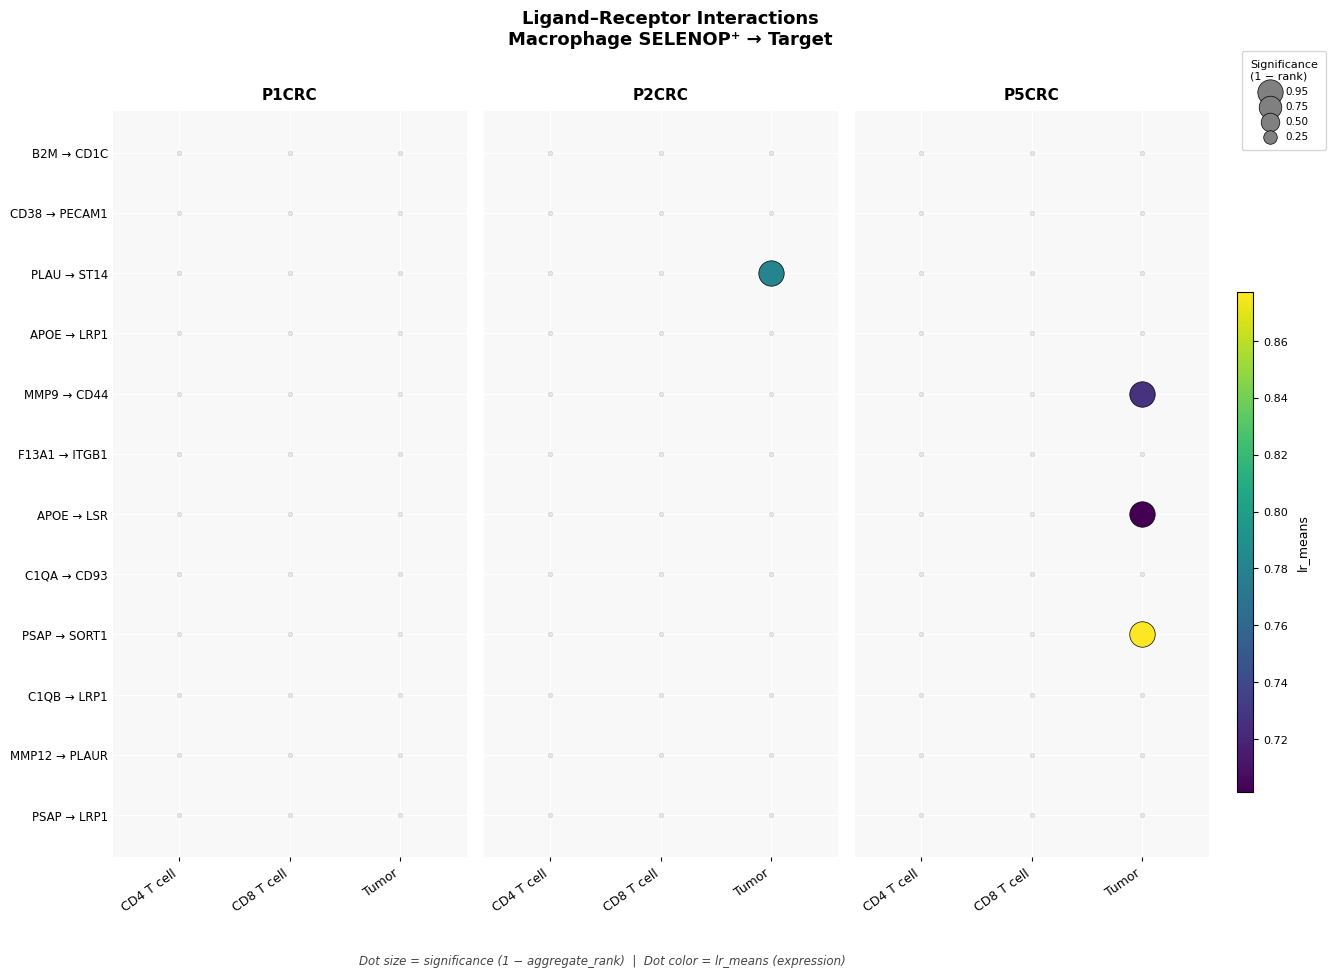

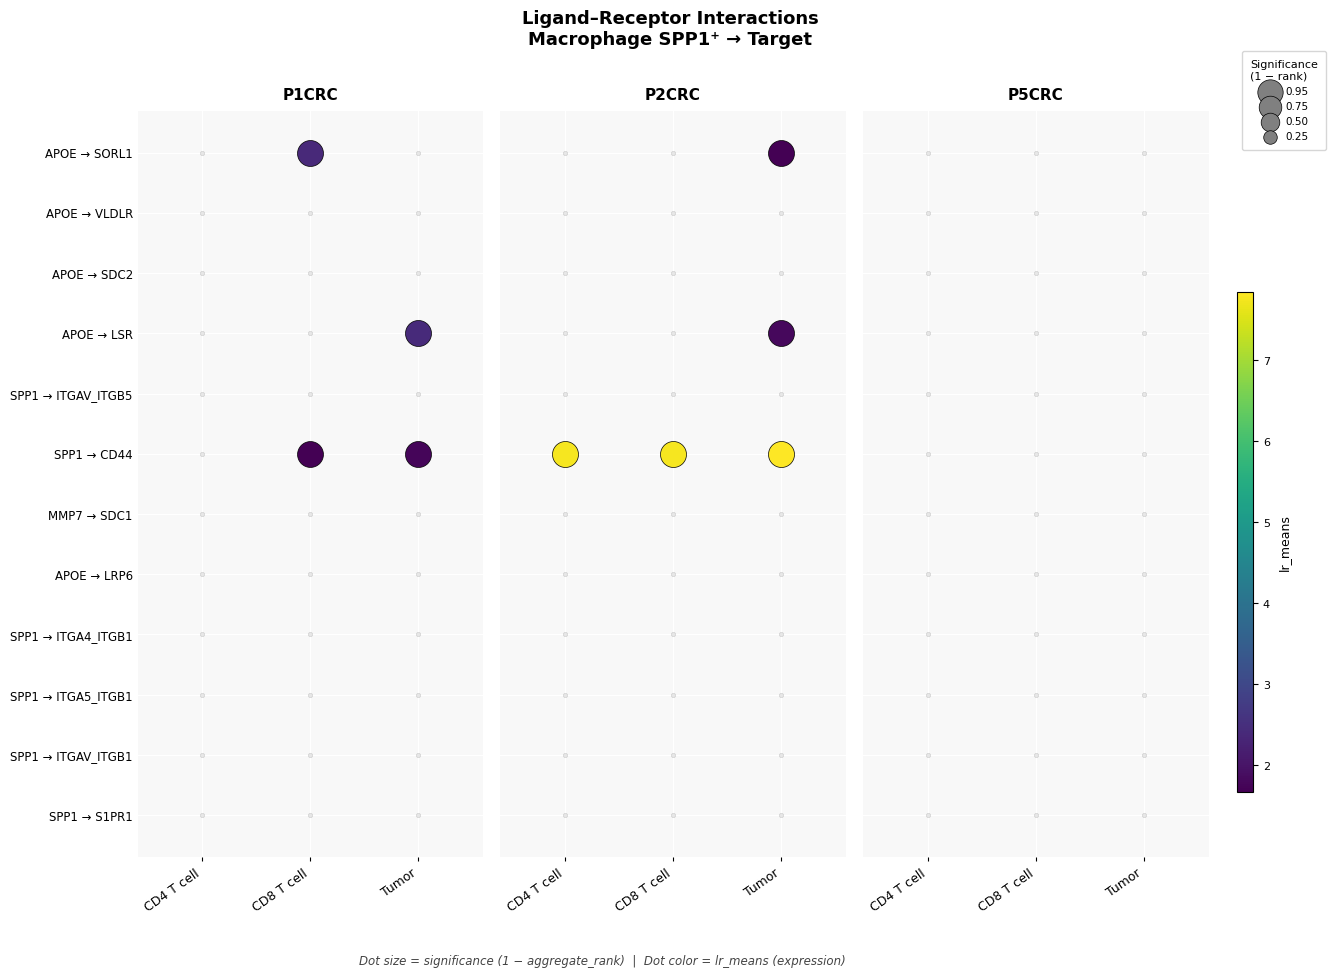

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Load and merge LIANA results ─────────────────────────────────────
frames = []
for sid, patient in [(0, 'P1CRC'), (1, 'P2CRC'), (2, 'P5CRC')]:
    sl = session.get_slice(sid)
    df = sl.adata.uns['liana_res'].copy()
    # Ensure Patient column is correct
    df['Patient'] = patient
    frames.append(df)

liana_all = pd.concat(frames, ignore_index=True)
print(f"Total LR rows (all patients, pre-filter): {len(liana_all):,}")

# ── Step 2: Filter to significant interactions ─────────────────────────────
liana_sig = liana_all[liana_all['aggregate_rank'] <= 0.05].copy()
print(f"Significant rows (aggregate_rank ≤ 0.05): {len(liana_sig):,}")

# ── Step 3: For each macrophage source, pick top-12 LR pairs ─────────────────
mac_sources = ["Macrophage_SELENOP+", "Macrophage_SPP1+"]
target_cells = ["CD4 T cell", "CD8 T cell", "Tumor"]

# Build LR label
liana_sig['lr_pair'] = (liana_sig['ligand_complex'].astype(str) + ' → ' +
                        liana_sig['receptor_complex'].astype(str))

top_lr = {}
for src in mac_sources:
    sub = liana_sig[liana_sig['source'] == src]
    if len(sub) == 0:
        print(f"  WARNING: No significant rows for source '{src}'")
        top_lr[src] = []
        continue
    # Mean aggregate_rank across patients × targets → lowest rank = strongest
    mean_ranks = (sub.groupby('lr_pair')['aggregate_rank']
                    .mean()
                    .sort_values(ascending=True)
                    .head(12))
    top_lr[src] = mean_ranks.index.tolist()
    print(f"\nTop-12 LR pairs for {src}:")
    for i, lr in enumerate(top_lr[src], 1):
        print(f"  {i:2d}. {lr}  (mean_rank={mean_ranks[lr]:.4f})")

# ── Helper: draw one faceted dotplot ─────────────────────────────────────────
def draw_dotplot(src, top_pairs, liana_sig, target_cells, patient_order):
    if len(top_pairs) == 0:
        print(f"Skipping plot for {src} — no significant interactions found.")
        return

    patients = patient_order
    n_patients = len(patients)
    n_pairs = len(top_pairs)
    n_targets = len(target_cells)

    fig_w = 4.5 * n_patients
    fig_h = max(5, 0.55 * n_pairs + 2.5)
    fig, axes = plt.subplots(1, n_patients,
                             figsize=(fig_w, fig_h),
                             sharey=True)
    if n_patients == 1:
        axes = [axes]

    # Global color range across all facets for this source
    sub_all = liana_sig[(liana_sig['source'] == src) &
                        (liana_sig['lr_pair'].isin(top_pairs)) &
                        (liana_sig['target'].isin(target_cells))]

    if 'lr_means' in sub_all.columns:
        color_col = 'lr_means'
    else:
        # Fallback: use 1 - aggregate_rank as color proxy
        color_col = None

    if color_col and len(sub_all) > 0:
        vmin = sub_all[color_col].quantile(0.02)
        vmax = sub_all[color_col].quantile(0.98)
    else:
        vmin, vmax = 0, 1

    cmap = cm.viridis
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # Dot size scale: significance = 1 - aggregate_rank → [0, 1]
    SIZE_MAX = 350
    SIZE_MIN = 10

    y_ticks = np.arange(n_pairs)
    x_ticks = np.arange(n_targets)

    for ax, pat in zip(axes, patients):
        sub_pat = sub_all[sub_all['Patient'] == pat]

        # Draw background grid
        ax.set_facecolor('#f8f8f8')
        for yi in y_ticks:
            ax.axhline(yi, color='white', lw=0.8, zorder=0)
        for xi in x_ticks:
            ax.axvline(xi, color='white', lw=0.8, zorder=0)

        for yi, lr in enumerate(top_pairs):
            for xi, tgt in enumerate(target_cells):
                row = sub_pat[(sub_pat['lr_pair'] == lr) &
                              (sub_pat['target'] == tgt)]
                if len(row) == 0:
                    # Grey empty dot
                    ax.scatter(xi, yi, s=SIZE_MIN, color='#d0d0d0',
                               edgecolors='#aaaaaa', linewidths=0.4,
                               zorder=2, alpha=0.5)
                    continue
                # Use best (lowest) aggregate_rank if duplicates
                row = row.nsmallest(1, 'aggregate_rank').iloc[0]
                sig  = 1.0 - float(row['aggregate_rank'])
                size = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * sig

                if color_col:
                    cval = float(row[color_col])
                else:
                    cval = sig
                rgba = cmap(norm(cval))

                ax.scatter(xi, yi, s=size, color=rgba,
                           edgecolors='black', linewidths=0.5,
                           zorder=3)

        ax.set_xlim(-0.6, n_targets - 0.4)
        ax.set_ylim(-0.7, n_pairs - 0.3)
        ax.set_xticks(x_ticks)
        ax.set_xticklabels(target_cells, rotation=35,
                           ha='right', fontsize=9)
        ax.set_title(pat, fontsize=11, fontweight='bold', pad=8)

        if ax is axes[0]:
            ax.set_yticks(y_ticks)
            ax.set_yticklabels(top_pairs, fontsize=8.5)
        ax.tick_params(axis='y', length=0)
        ax.tick_params(axis='x', length=3)
        for spine in ax.spines.values():
            spine.set_visible(False)

    # Colorbar
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.92, 0.15, 0.012, 0.55])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label(color_col if color_col else '1 − agg_rank',
                   fontsize=9, labelpad=6)
    cbar.ax.tick_params(labelsize=8)

    # Size legend
    legend_ax = fig.add_axes([0.92, 0.72, 0.07, 0.22])
    legend_ax.set_visible(False)
    for sig_val, label in [(0.95, '0.95'), (0.75, '0.75'),
                           (0.50, '0.50'), (0.25, '0.25')]:
        sz = SIZE_MIN + (SIZE_MAX - SIZE_MIN) * sig_val
        legend_ax.scatter([], [], s=sz, color='grey',
                          edgecolors='black', linewidths=0.5,
                          label=f'{label}')
    fig.legend(*legend_ax.get_legend_handles_labels(),
               title='Significance\n(1 − rank)', fontsize=7.5,
               title_fontsize=8, loc='upper right',
               bbox_to_anchor=(0.99, 0.97),
               frameon=True, edgecolor='#cccccc',
               ncol=1, handletextpad=0.4, borderpad=0.8)

    src_clean = src.replace('+', '⁺').replace('_', ' ')
    fig.suptitle(f'Ligand–Receptor Interactions\n{src_clean} → Target',
                 fontsize=13, fontweight='bold', y=1.01)

    color_label = 'lr_means (expression)' if color_col else '1 − aggregate_rank'
    fig.text(0.45, -0.04,
             f'Dot size = significance (1 − aggregate_rank)  |  '
             f'Dot color = {color_label}',
             ha='center', fontsize=8.5, color='#444444',
             style='italic')

    plt.tight_layout(rect=[0, 0, 0.91, 1.0])
    plt.show()

# ── Step 4: Draw figures ───────────────────────────────────────────────────
patient_order = ['P1CRC', 'P2CRC', 'P5CRC']

for src in mac_sources:
    draw_dotplot(src, top_lr[src], liana_sig, target_cells, patient_order)